In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


In [2]:
# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
P = 5.0     # Penalty for concealing
phi_t = 0.9 # Decreasing factor of reward over time (e.g., 90% of original reward)

In [5]:
# Payoff functions
def pi_R(x):
    """Payoff for using the Reveal strategy."""
    return x * (phi_t * r - C_d) + (1 - x) * (-C_a)

def pi_C(x):
    """Payoff for using the Conceal strategy."""
    return x * (phi_t * r - C_d) + (1 - x) * (-C_a - P)

def average_payoff(x):
    """Average payoff across the population."""
    return x * pi_R(x) + (1 - x) * pi_C(x)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t):
    pi_R_x = pi_R(x)
    avg_pi = average_payoff(x)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

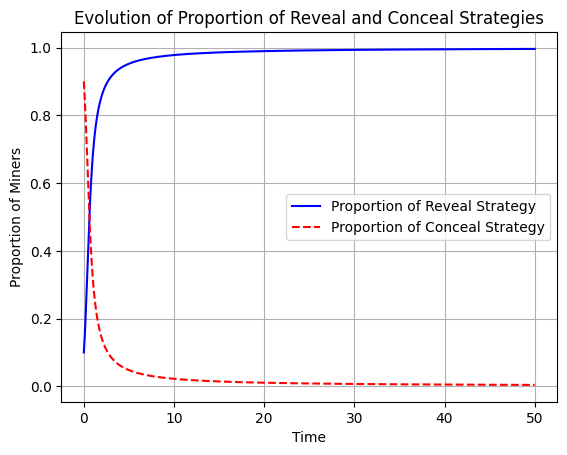

In [7]:
# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 50, 500)

# Solve the replicator dynamics equation using odeint
x_trajectory = odeint(replicator_dynamics, x0, time_points)
conceal_trajectory = 1 - x_trajectory

# Plot the results
plt.plot(time_points, x_trajectory, label="Proportion of Reveal Strategy",  color='blue')
plt.plot(time_points, conceal_trajectory, label="Proportion of Conceal Strategy", color='red', linestyle='--')

plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies')
plt.grid(True)
plt.legend()
plt.show()

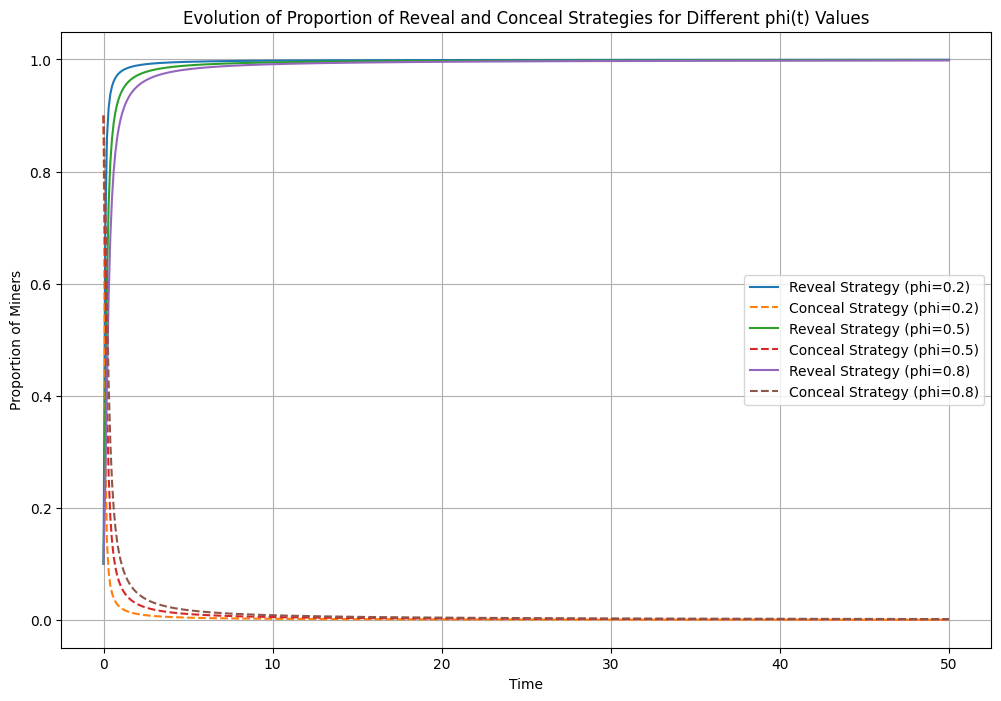

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as [phi(t)]^-1 * r."""
    return (1 / phi_t) * r

# Payoff functions
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy."""
    return x * (phi_t * r - C_d) + (1 - x) * (-C_a)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy."""
    return x * (phi_t * r - C_d) + (1 - x) * (-C_a - P)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 50, 500)

# Values of phi(t) to simulate
phi_values = [0.2, 0.5, 0.8]  # Different values of phi(t) between 0 and 1

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies for Different phi(t) Values')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
#### now we wanna make it complex to add reputation and show the convergence point

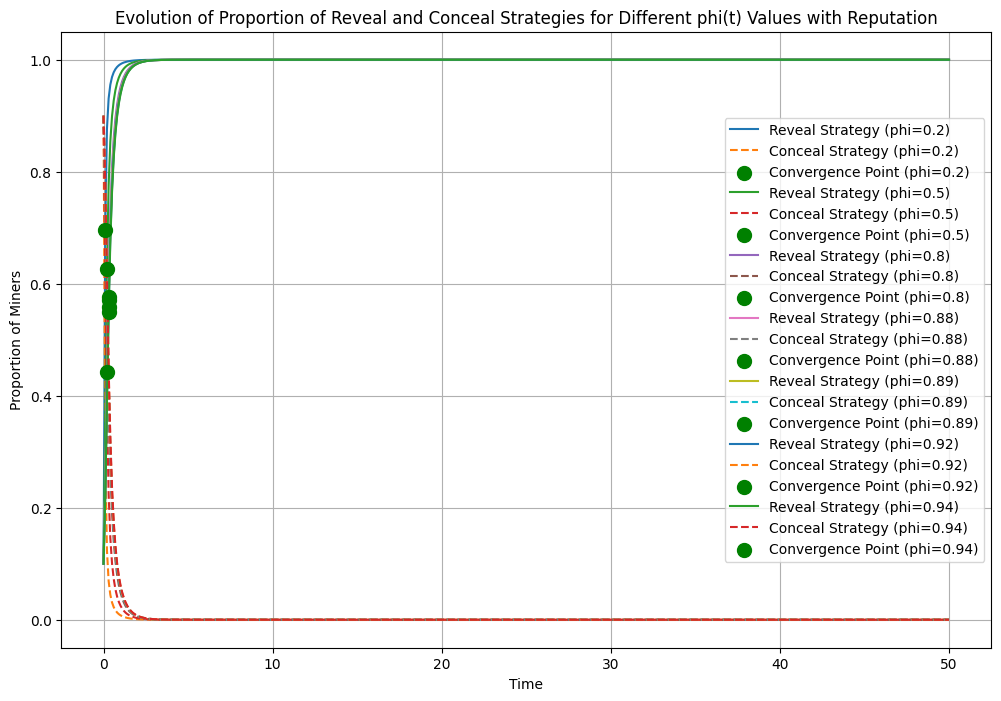

Convergence for phi=0.2: Time = 0.10, Proportion of miners revealing = 0.70
Convergence for phi=0.5: Time = 0.20, Proportion of miners revealing = 0.63
Convergence for phi=0.8: Time = 0.20, Proportion of miners revealing = 0.44
Convergence for phi=0.88: Time = 0.30, Proportion of miners revealing = 0.58
Convergence for phi=0.89: Time = 0.30, Proportion of miners revealing = 0.57
Convergence for phi=0.92: Time = 0.30, Proportion of miners revealing = 0.56
Convergence for phi=0.94: Time = 0.30, Proportion of miners revealing = 0.55


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as [phi(t)]^-1 * r."""
    return (1 / phi_t) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 50, 500)

# Values of phi(t) to simulate
phi_values = [0.2, 0.5, 0.8, 0.88, 0.89, 0.92,0.94]  # Different values of phi(t) between 0 and 1

# List to store convergence information
convergence_info = []

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")
    plt.scatter(intersection_time, intersection_value, color='green', s=100, label=f"Convergence Point (phi={phi_t})", zorder=5)

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies for Different phi(t) Values with Reputation')
plt.grid(True)
plt.legend()
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [31]:
## now change the punishment function and the range of phi:

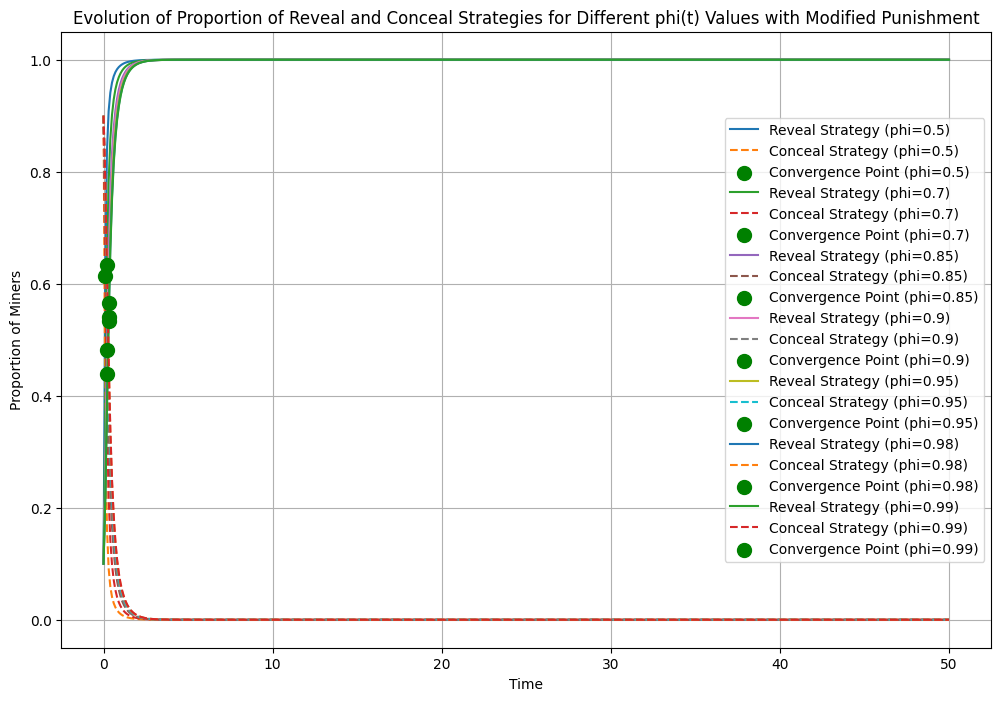

Convergence for phi=0.5: Time = 0.10, Proportion of miners revealing = 0.61
Convergence for phi=0.7: Time = 0.20, Proportion of miners revealing = 0.63
Convergence for phi=0.85: Time = 0.20, Proportion of miners revealing = 0.48
Convergence for phi=0.9: Time = 0.20, Proportion of miners revealing = 0.44
Convergence for phi=0.95: Time = 0.30, Proportion of miners revealing = 0.57
Convergence for phi=0.98: Time = 0.30, Proportion of miners revealing = 0.54
Convergence for phi=0.99: Time = 0.30, Proportion of miners revealing = 0.53


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 50, 500)

# Values of phi(t) to simulate (closer to 1)
phi_values = [0.5, 0.7, 0.85, 0.9, 0.95, 0.98, 0.99]

# List to store convergence information
convergence_info = []

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")
    plt.scatter(intersection_time, intersection_value, color='green', s=100, label=f"Convergence Point (phi={phi_t})", zorder=5)

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies for Different phi(t) Values with Modified Punishment')
plt.grid(True)
plt.legend()
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [ ]:
# changing the range of phi to [0.1 - 0.7]:

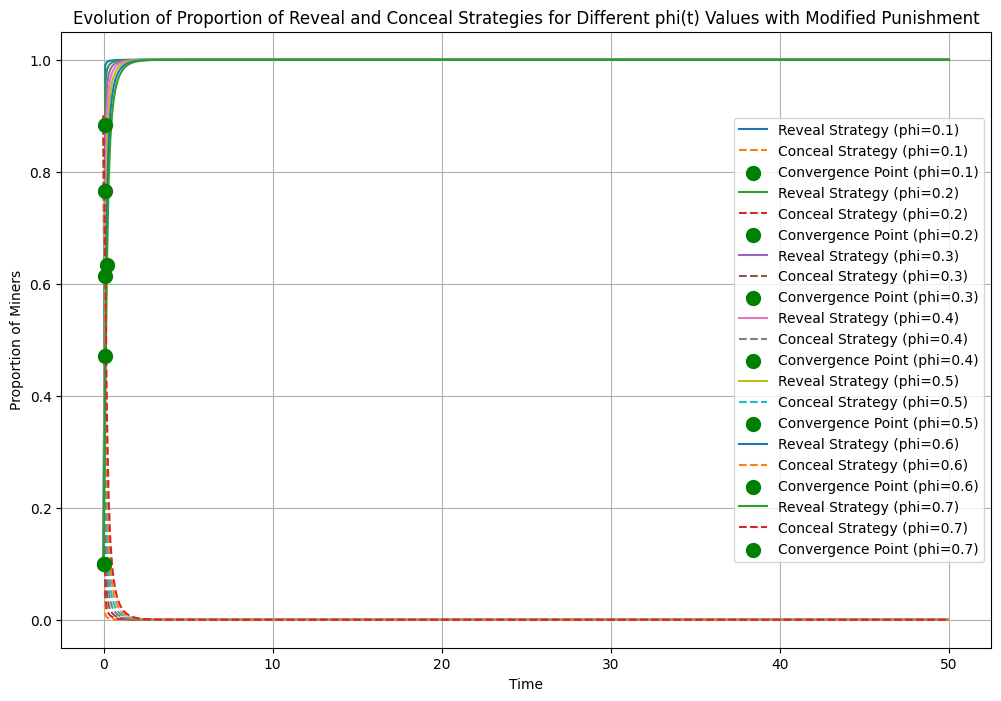

Convergence for phi=0.1: Time = 0.00, Proportion of miners revealing = 0.10
Convergence for phi=0.2: Time = 0.00, Proportion of miners revealing = 0.10
Convergence for phi=0.3: Time = 0.10, Proportion of miners revealing = 0.88
Convergence for phi=0.4: Time = 0.10, Proportion of miners revealing = 0.76
Convergence for phi=0.5: Time = 0.10, Proportion of miners revealing = 0.61
Convergence for phi=0.6: Time = 0.10, Proportion of miners revealing = 0.47
Convergence for phi=0.7: Time = 0.20, Proportion of miners revealing = 0.63


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 50, 500)

# Values of phi(t) to simulate (closer to 1)
phi_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# List to store convergence information
convergence_info = []

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")
    plt.scatter(intersection_time, intersection_value, color='green', s=100, label=f"Convergence Point (phi={phi_t})", zorder=5)

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies for Different phi(t) Values with Modified Punishment')
plt.grid(True)
plt.legend()
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [ ]:
# saving as pdf

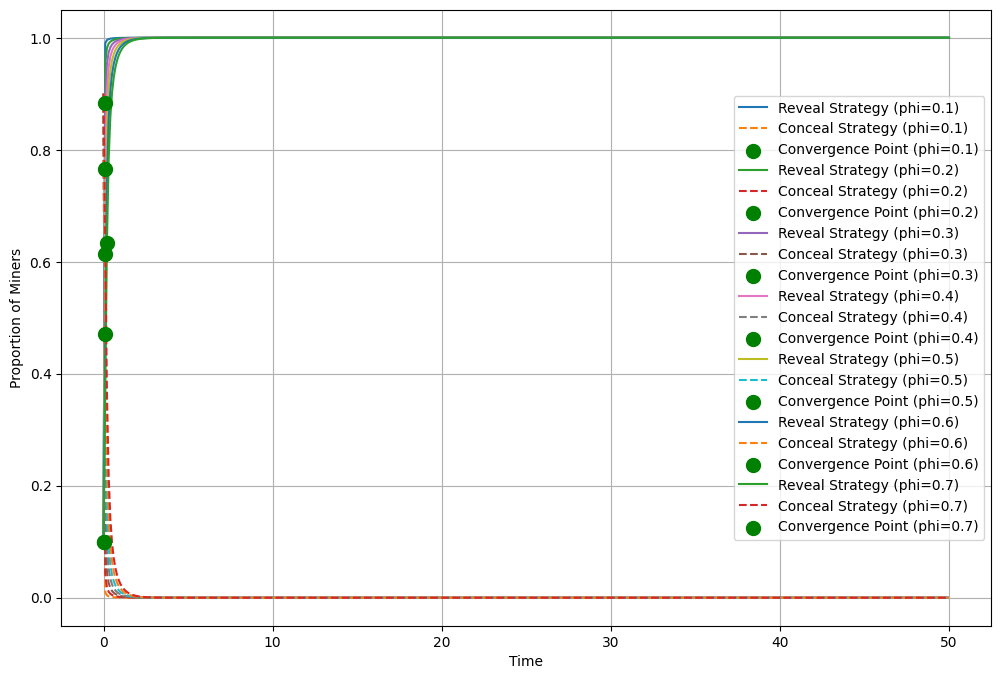

Convergence for phi=0.1: Time = 0.00, Proportion of miners revealing = 0.10
Convergence for phi=0.2: Time = 0.00, Proportion of miners revealing = 0.10
Convergence for phi=0.3: Time = 0.10, Proportion of miners revealing = 0.88
Convergence for phi=0.4: Time = 0.10, Proportion of miners revealing = 0.76
Convergence for phi=0.5: Time = 0.10, Proportion of miners revealing = 0.61
Convergence for phi=0.6: Time = 0.10, Proportion of miners revealing = 0.47
Convergence for phi=0.7: Time = 0.20, Proportion of miners revealing = 0.63


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 50, 500)

# Values of phi(t) to simulate (closer to 1)
phi_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# List to store convergence information
convergence_info = []

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")
    plt.scatter(intersection_time, intersection_value, color='green', s=100, label=f"Convergence Point (phi={phi_t})", zorder=5)

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('')
plt.grid(True)
plt.legend()

# Save the figure as a PDF
plt.savefig('strategy_evolution2.pdf', format='pdf')

# Show the plot
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [ ]:
# change the range of t to have [0 - 10]

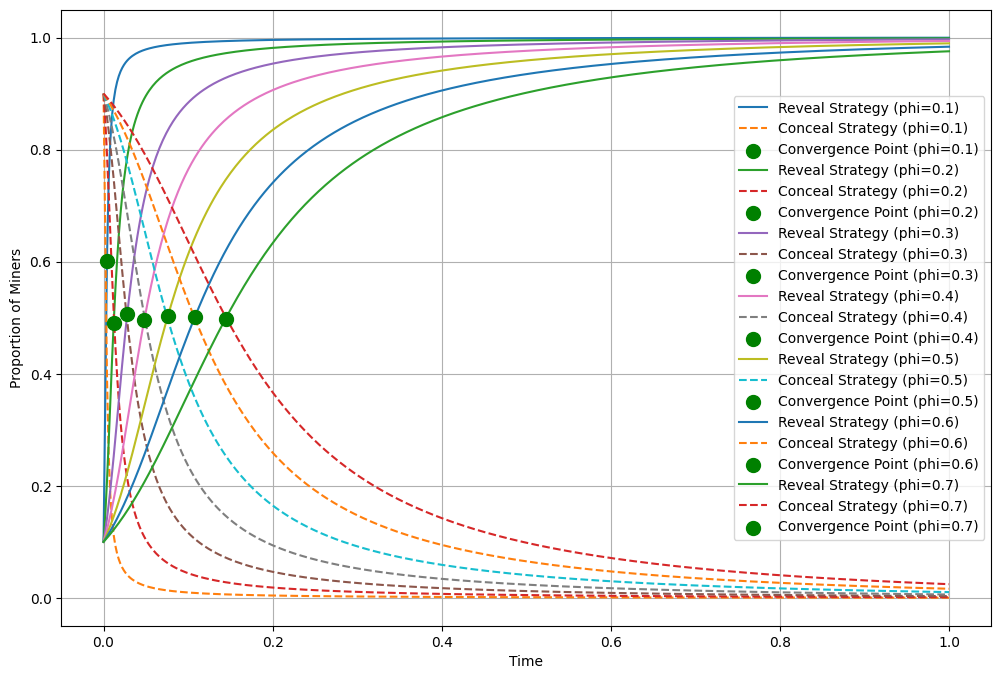

Convergence for phi=0.1: Time = 0.00, Proportion of miners revealing = 0.60
Convergence for phi=0.2: Time = 0.01, Proportion of miners revealing = 0.49
Convergence for phi=0.3: Time = 0.03, Proportion of miners revealing = 0.51
Convergence for phi=0.4: Time = 0.05, Proportion of miners revealing = 0.50
Convergence for phi=0.5: Time = 0.08, Proportion of miners revealing = 0.50
Convergence for phi=0.6: Time = 0.11, Proportion of miners revealing = 0.50
Convergence for phi=0.7: Time = 0.14, Proportion of miners revealing = 0.50


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 1, 500)

# Values of phi(t) to simulate (closer to 1)
phi_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# List to store convergence information
convergence_info = []

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")
    plt.scatter(intersection_time, intersection_value, color='green', s=100, label=f"Convergence Point (phi={phi_t})", zorder=5)

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('')
plt.grid(True)
plt.legend()

# Save the figure as a PDF
plt.savefig('strategy_evolution5.pdf', format='pdf')

# Show the plot
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [ ]:
## removing convergence point from the figure:

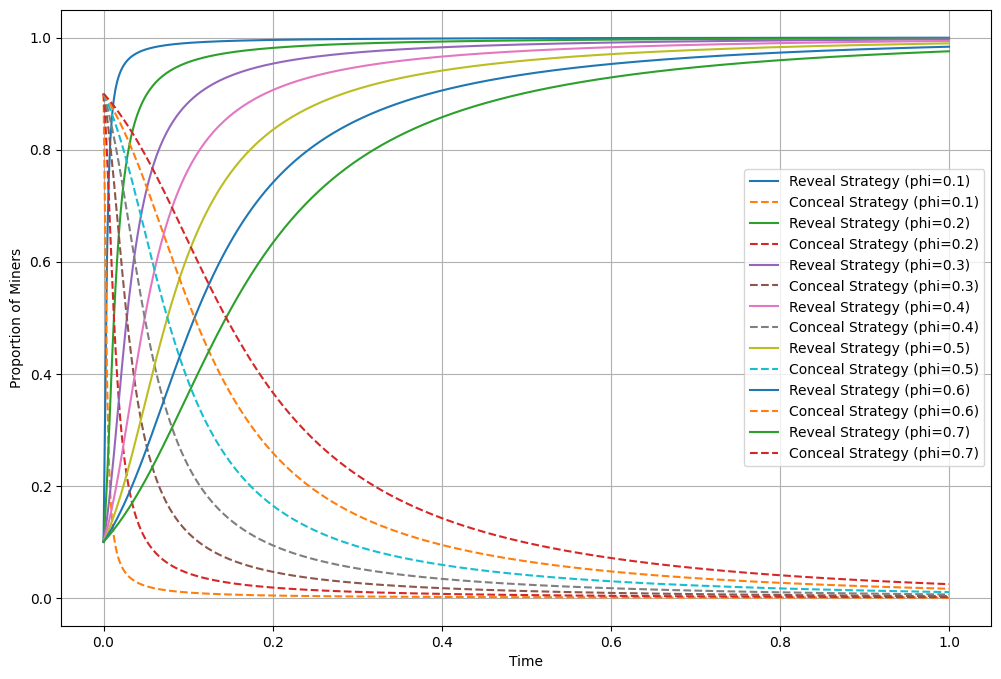

Convergence for phi=0.1: Time = 0.00, Proportion of miners revealing = 0.60
Convergence for phi=0.2: Time = 0.01, Proportion of miners revealing = 0.49
Convergence for phi=0.3: Time = 0.03, Proportion of miners revealing = 0.51
Convergence for phi=0.4: Time = 0.05, Proportion of miners revealing = 0.50
Convergence for phi=0.5: Time = 0.08, Proportion of miners revealing = 0.50
Convergence for phi=0.6: Time = 0.11, Proportion of miners revealing = 0.50
Convergence for phi=0.7: Time = 0.14, Proportion of miners revealing = 0.50


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 1, 500)

# Values of phi(t) to simulate
phi_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# List to store convergence information
convergence_info = []

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Store the convergence information (without plotting convergence points)
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]
    intersection_value = x_trajectory[intersection_idx][0]
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results for "Reveal" and "Conceal" strategies
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('')
plt.grid(True)
plt.legend()

# Save the figure as a PDF
plt.savefig('strategy_evolution6.pdf', format='pdf')

# Show the plot
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [ ]:
### all possible values for phi(t) and t between 0-1

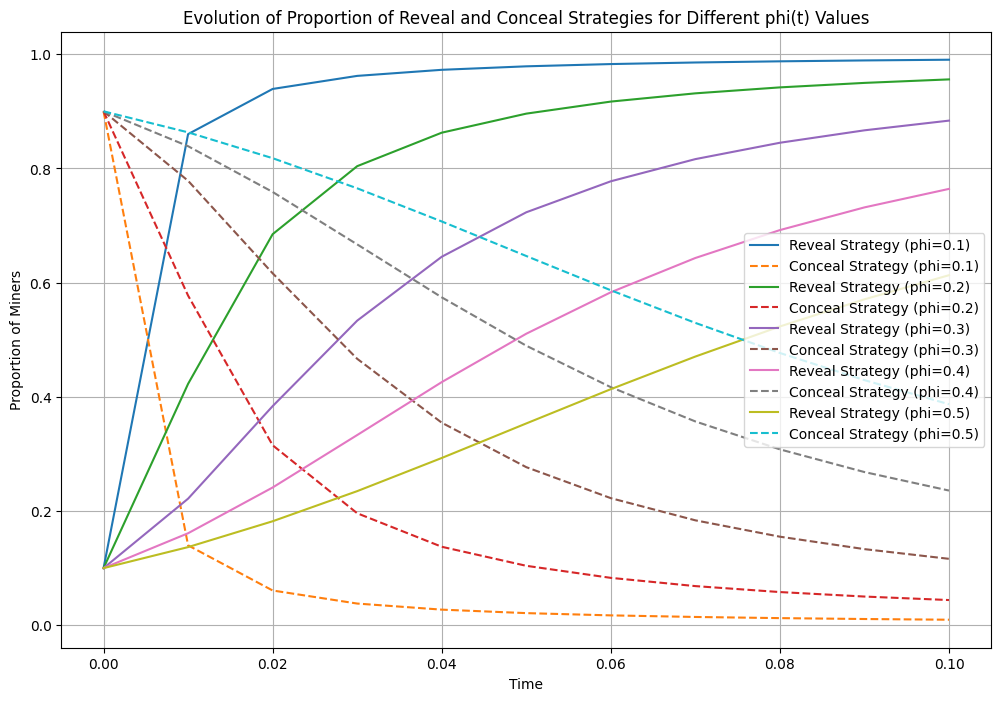

phi=0.1, Time=0.00, Proportion of miners revealing=0.10
phi=0.1, Time=0.01, Proportion of miners revealing=0.86
phi=0.1, Time=0.02, Proportion of miners revealing=0.94
phi=0.1, Time=0.03, Proportion of miners revealing=0.96
phi=0.1, Time=0.04, Proportion of miners revealing=0.97
phi=0.1, Time=0.05, Proportion of miners revealing=0.98
phi=0.1, Time=0.06, Proportion of miners revealing=0.98
phi=0.1, Time=0.07, Proportion of miners revealing=0.99
phi=0.1, Time=0.08, Proportion of miners revealing=0.99
phi=0.1, Time=0.09, Proportion of miners revealing=0.99
phi=0.1, Time=0.10, Proportion of miners revealing=0.99
phi=0.2, Time=0.00, Proportion of miners revealing=0.10
phi=0.2, Time=0.01, Proportion of miners revealing=0.42
phi=0.2, Time=0.02, Proportion of miners revealing=0.68
phi=0.2, Time=0.03, Proportion of miners revealing=0.80
phi=0.2, Time=0.04, Proportion of miners revealing=0.86
phi=0.2, Time=0.05, Proportion of miners revealing=0.90
phi=0.2, Time=0.06, Proportion of miners reveali

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 0.1, 11)

# Values of phi(t) to simulate
phi_values = [0.1, 0.2, 0.3, 0.4, 0.5]

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Plot the results for "Reveal" and "Conceal" strategies
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies for Different phi(t) Values')
plt.grid(True)
plt.legend()

# Save the figure as a PDF
plt.savefig('strategy_evolution_time_short.pdf', format='pdf')

# Show the plot
plt.show()

# Print the convergence information for the chosen time points
for phi_t in phi_values:
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))
    for t, x in zip(time_points, x_trajectory):
        print(f"phi={phi_t}, Time={t:.2f}, Proportion of miners revealing={x[0]:.2f}")


In [3]:
###############3 have several figures@@@@@@@@@@@@@@@@@@@@@@@@@

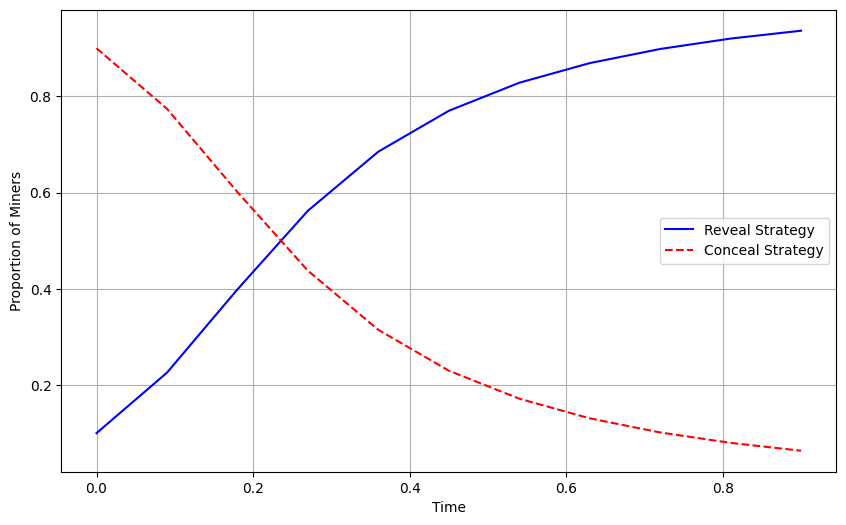


Results for phi=0.9:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.23
Time=0.18, Proportion of miners revealing=0.40
Time=0.27, Proportion of miners revealing=0.56
Time=0.36, Proportion of miners revealing=0.69
Time=0.45, Proportion of miners revealing=0.77
Time=0.54, Proportion of miners revealing=0.83
Time=0.63, Proportion of miners revealing=0.87
Time=0.72, Proportion of miners revealing=0.90
Time=0.81, Proportion of miners revealing=0.92
Time=0.90, Proportion of miners revealing=0.94


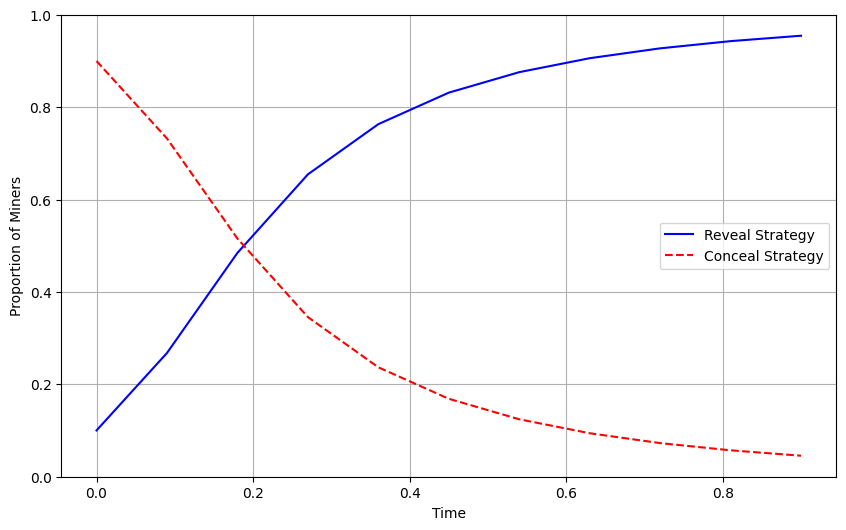


Results for phi=0.8:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.27
Time=0.18, Proportion of miners revealing=0.48
Time=0.27, Proportion of miners revealing=0.65
Time=0.36, Proportion of miners revealing=0.76
Time=0.45, Proportion of miners revealing=0.83
Time=0.54, Proportion of miners revealing=0.88
Time=0.63, Proportion of miners revealing=0.91
Time=0.72, Proportion of miners revealing=0.93
Time=0.81, Proportion of miners revealing=0.94
Time=0.90, Proportion of miners revealing=0.95


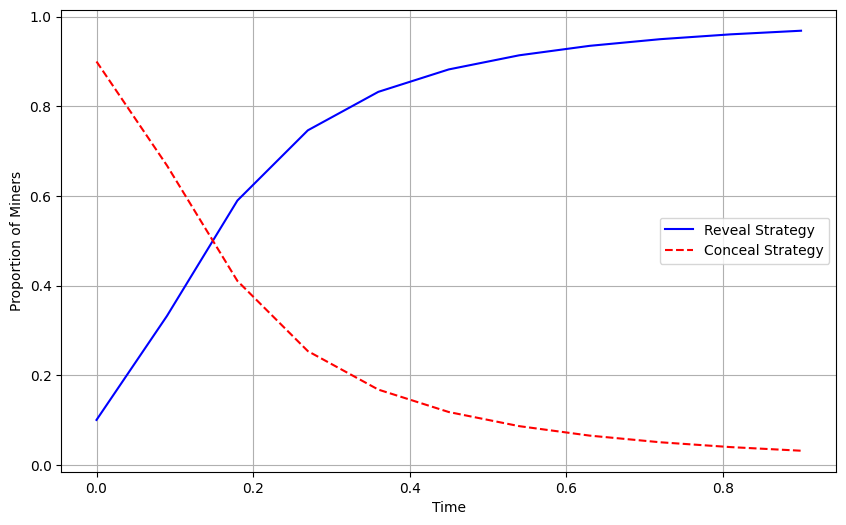


Results for phi=0.7:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.33
Time=0.18, Proportion of miners revealing=0.59
Time=0.27, Proportion of miners revealing=0.75
Time=0.36, Proportion of miners revealing=0.83
Time=0.45, Proportion of miners revealing=0.88
Time=0.54, Proportion of miners revealing=0.91
Time=0.63, Proportion of miners revealing=0.93
Time=0.72, Proportion of miners revealing=0.95
Time=0.81, Proportion of miners revealing=0.96
Time=0.90, Proportion of miners revealing=0.97


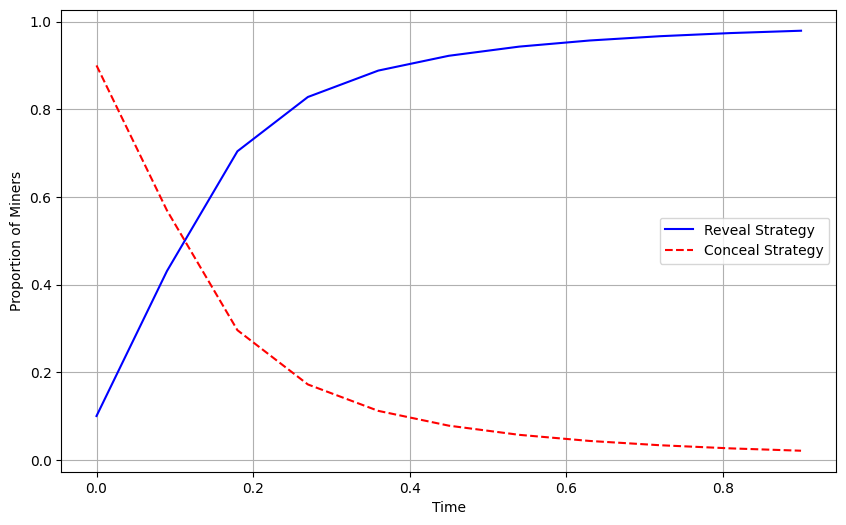


Results for phi=0.6:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.43
Time=0.18, Proportion of miners revealing=0.70
Time=0.27, Proportion of miners revealing=0.83
Time=0.36, Proportion of miners revealing=0.89
Time=0.45, Proportion of miners revealing=0.92
Time=0.54, Proportion of miners revealing=0.94
Time=0.63, Proportion of miners revealing=0.96
Time=0.72, Proportion of miners revealing=0.97
Time=0.81, Proportion of miners revealing=0.97
Time=0.90, Proportion of miners revealing=0.98


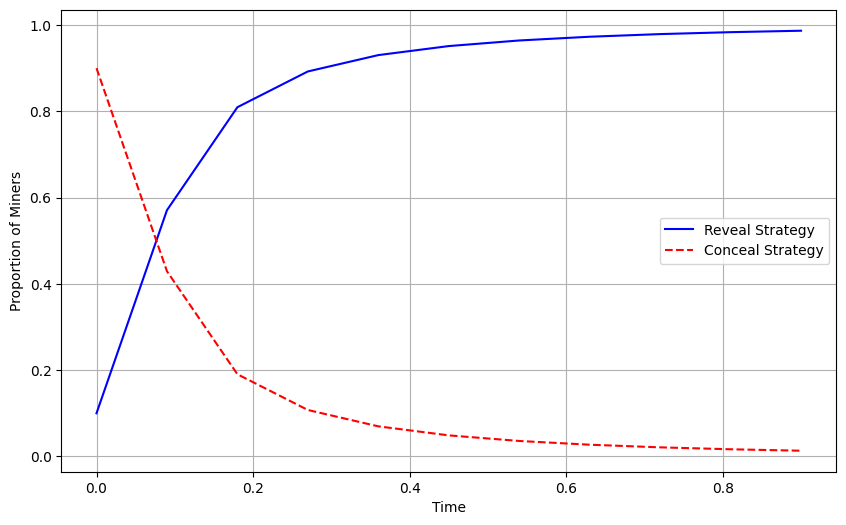


Results for phi=0.5:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.57
Time=0.18, Proportion of miners revealing=0.81
Time=0.27, Proportion of miners revealing=0.89
Time=0.36, Proportion of miners revealing=0.93
Time=0.45, Proportion of miners revealing=0.95
Time=0.54, Proportion of miners revealing=0.96
Time=0.63, Proportion of miners revealing=0.97
Time=0.72, Proportion of miners revealing=0.98
Time=0.81, Proportion of miners revealing=0.98
Time=0.90, Proportion of miners revealing=0.99


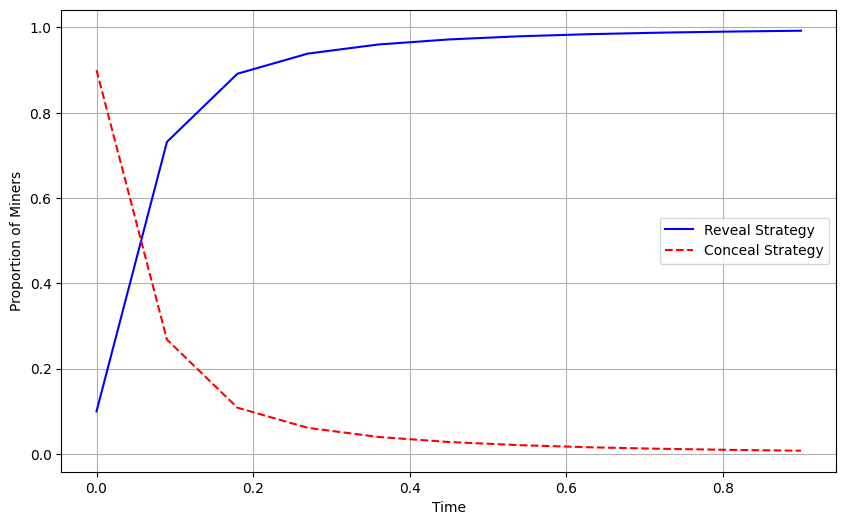


Results for phi=0.4:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.73
Time=0.18, Proportion of miners revealing=0.89
Time=0.27, Proportion of miners revealing=0.94
Time=0.36, Proportion of miners revealing=0.96
Time=0.45, Proportion of miners revealing=0.97
Time=0.54, Proportion of miners revealing=0.98
Time=0.63, Proportion of miners revealing=0.98
Time=0.72, Proportion of miners revealing=0.99
Time=0.81, Proportion of miners revealing=0.99
Time=0.90, Proportion of miners revealing=0.99


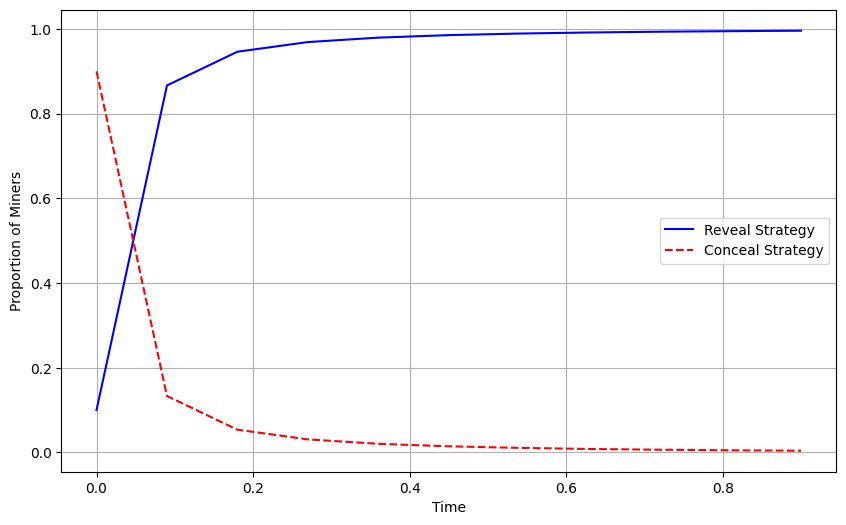


Results for phi=0.3:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.87
Time=0.18, Proportion of miners revealing=0.95
Time=0.27, Proportion of miners revealing=0.97
Time=0.36, Proportion of miners revealing=0.98
Time=0.45, Proportion of miners revealing=0.99
Time=0.54, Proportion of miners revealing=0.99
Time=0.63, Proportion of miners revealing=0.99
Time=0.72, Proportion of miners revealing=0.99
Time=0.81, Proportion of miners revealing=0.99
Time=0.90, Proportion of miners revealing=1.00


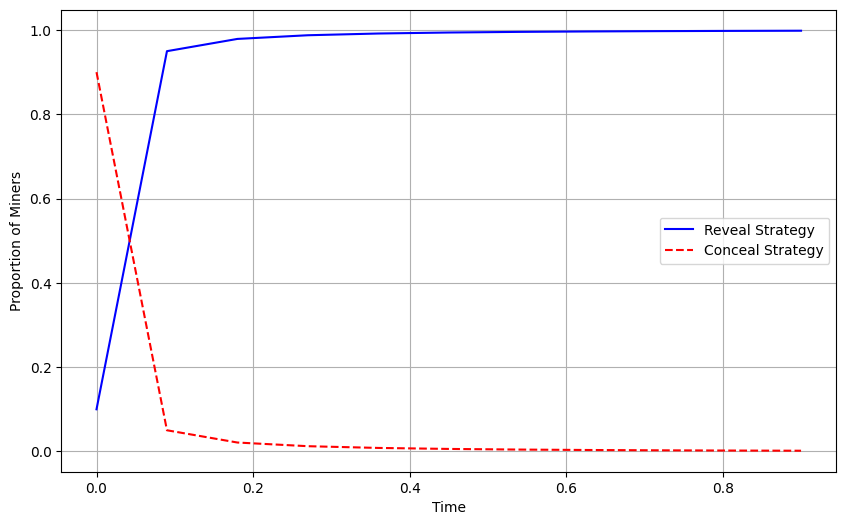


Results for phi=0.2:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.95
Time=0.18, Proportion of miners revealing=0.98
Time=0.27, Proportion of miners revealing=0.99
Time=0.36, Proportion of miners revealing=0.99
Time=0.45, Proportion of miners revealing=0.99
Time=0.54, Proportion of miners revealing=1.00
Time=0.63, Proportion of miners revealing=1.00
Time=0.72, Proportion of miners revealing=1.00
Time=0.81, Proportion of miners revealing=1.00
Time=0.90, Proportion of miners revealing=1.00


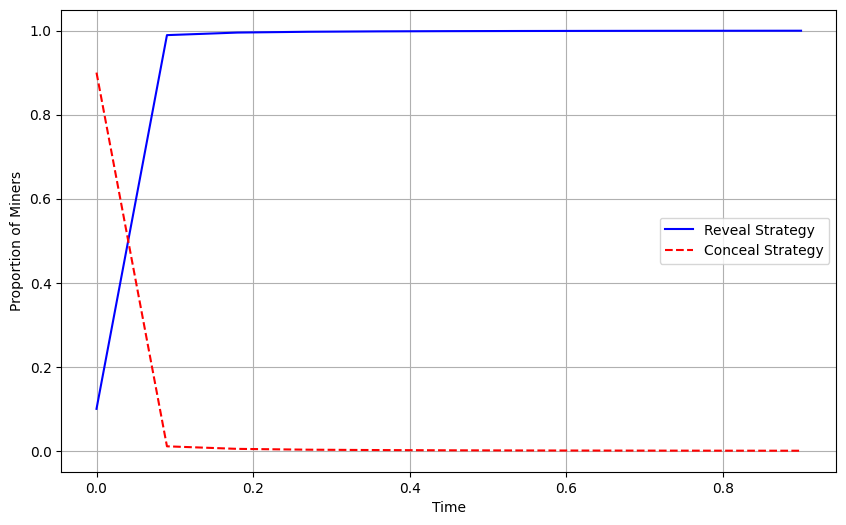


Results for phi=0.1:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.99
Time=0.18, Proportion of miners revealing=1.00
Time=0.27, Proportion of miners revealing=1.00
Time=0.36, Proportion of miners revealing=1.00
Time=0.45, Proportion of miners revealing=1.00
Time=0.54, Proportion of miners revealing=1.00
Time=0.63, Proportion of miners revealing=1.00
Time=0.72, Proportion of miners revealing=1.00
Time=0.81, Proportion of miners revealing=1.00
Time=0.90, Proportion of miners revealing=1.00


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 0.9, 11)

# Values of phi(t) to simulate in reverse order (0.9 to 0.1)
phi_values = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

# Plot separate figures for each value of phi(t)
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Create a new figure for each phi(t)
    plt.figure(figsize=(10, 6))
    
    # Plot the results for "Reveal" and "Conceal" strategies
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy", color='b')
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy", color='r')
    
    # Plot settings
    plt.xlabel('Time')
    plt.ylabel('Proportion of Miners')
    plt.title('')
    plt.grid(True)
    # Adjust the legend position
    plt.legend(loc='center right', bbox_to_anchor=(1, 0.5))
    
    # Save the figure as a PDF for each phi(t)
    plt.savefig(f'strategy_evolution_phi_{phi_t}.pdf', format='pdf')
    
    # Show the plot
    plt.show()

    # Print the results for this phi(t)
    print(f"\nResults for phi={phi_t}:")
    for t, x in zip(time_points, x_trajectory):
        print(f"Time={t:.2f}, Proportion of miners revealing={x[0]:.2f}")


In [ ]:
## ############# the following code: NOOOOOOOO 

In [4]:
########## having variable phi(t)

########################## we assume \[\phi(t) = 0.1 + 0.9 \cdot e^{-kt}\] where\( e \) is the base of the natural logarithm, approximately equal to 2.718, used to define the exponential decay.
#  % and \( k \) is a decay constant that controls the rate of decrease of \( \phi(t) \). A higher value of \( k \) results in a faster decay.

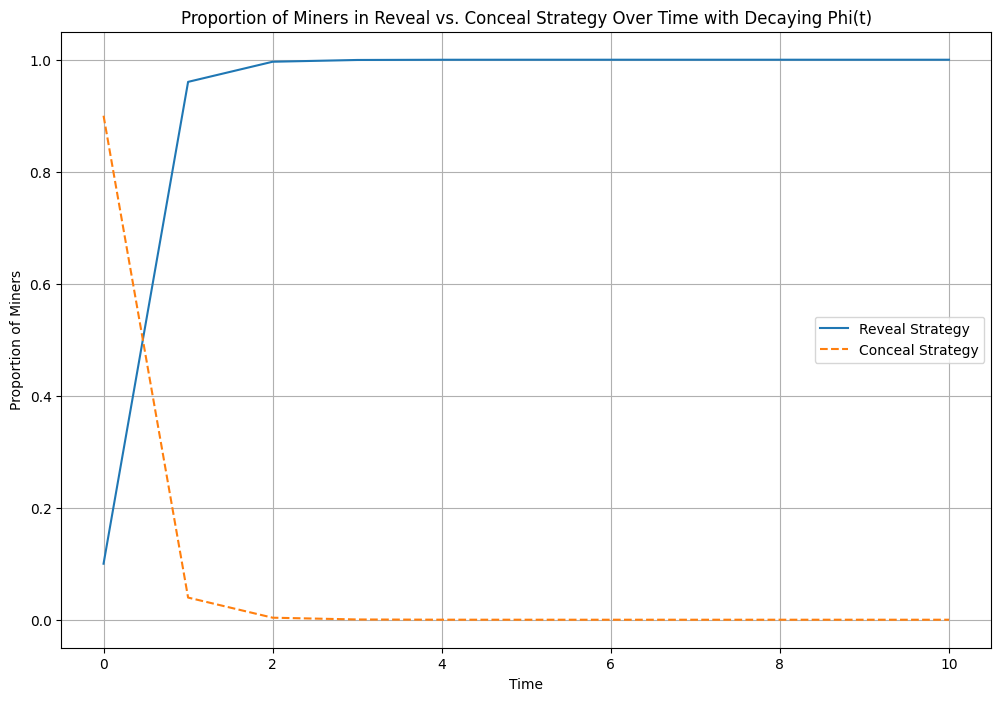

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Non-linear, exponentially decaying phi(t)
def phi_t(t, k=0.5):
    """Exponentially decaying function for phi(t) from 1 to 0.1 over time."""
    return 0.1 + (1 - 0.1) * np.exp(-k * t)

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi, t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi, P, t):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi, P, t):
    """Average payoff across the population."""
    return x * pi_R(x, phi, t) + (1 - x) * pi_C(x, phi, P, t)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t):
    phi = phi_t(t, k=0.5)  # Update phi based on time using exponential decay
    P = calculate_punishment(phi, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi, t)
    avg_pi = average_payoff(x, phi, P, t)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation, from 0 to 10 in steps of 1
time_points = np.arange(0, 11, 1)

# Solve the replicator dynamics equation using odeint
x_trajectory = odeint(replicator_dynamics, x0, time_points)

# Calculate the proportion of miners using the Conceal strategy
conceal_trajectory = 1 - x_trajectory

# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(time_points, x_trajectory, label="Reveal Strategy")
plt.plot(time_points, conceal_trajectory, linestyle='--', label="Conceal Strategy")
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Proportion of Miners in Reveal vs. Conceal Strategy Over Time with Decaying Phi(t)')
plt.grid(True)
plt.legend()

# Save the figure as a PDF
plt.savefig('strategy_evolution_non_linear_phi.pdf', format='pdf')

# Show the plot
plt.show()


In [ ]:
############ some changes like dynamic punishment, variable reputation,...

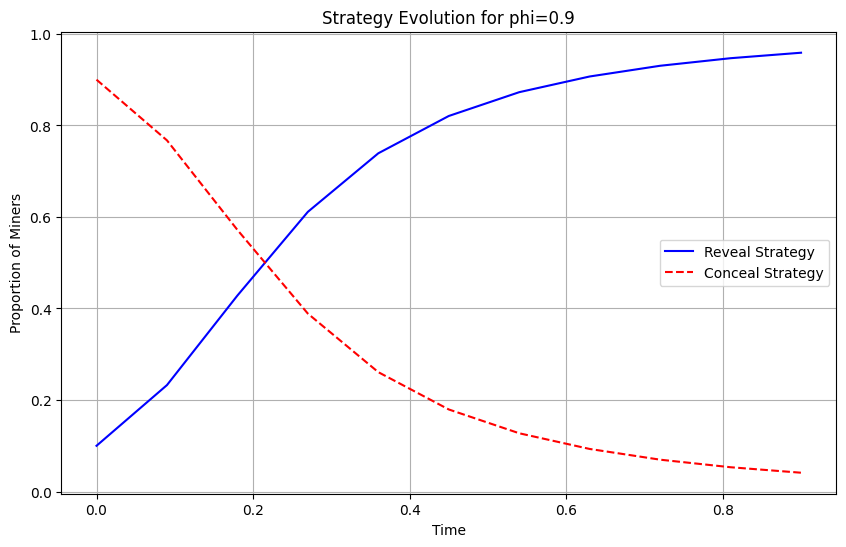


Results for phi=0.9:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.23
Time=0.18, Proportion of miners revealing=0.43
Time=0.27, Proportion of miners revealing=0.61
Time=0.36, Proportion of miners revealing=0.74
Time=0.45, Proportion of miners revealing=0.82
Time=0.54, Proportion of miners revealing=0.87
Time=0.63, Proportion of miners revealing=0.91
Time=0.72, Proportion of miners revealing=0.93
Time=0.81, Proportion of miners revealing=0.95
Time=0.90, Proportion of miners revealing=0.96


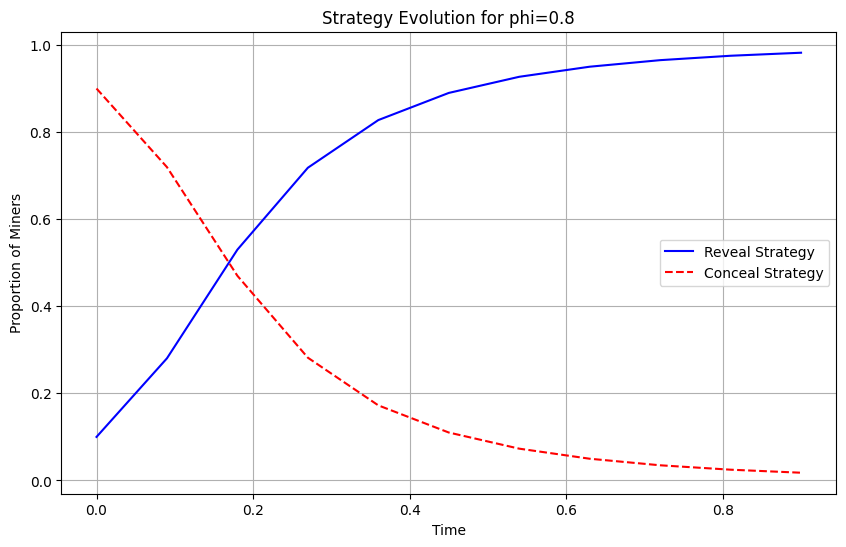


Results for phi=0.8:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.28
Time=0.18, Proportion of miners revealing=0.53
Time=0.27, Proportion of miners revealing=0.72
Time=0.36, Proportion of miners revealing=0.83
Time=0.45, Proportion of miners revealing=0.89
Time=0.54, Proportion of miners revealing=0.93
Time=0.63, Proportion of miners revealing=0.95
Time=0.72, Proportion of miners revealing=0.97
Time=0.81, Proportion of miners revealing=0.98
Time=0.90, Proportion of miners revealing=0.98


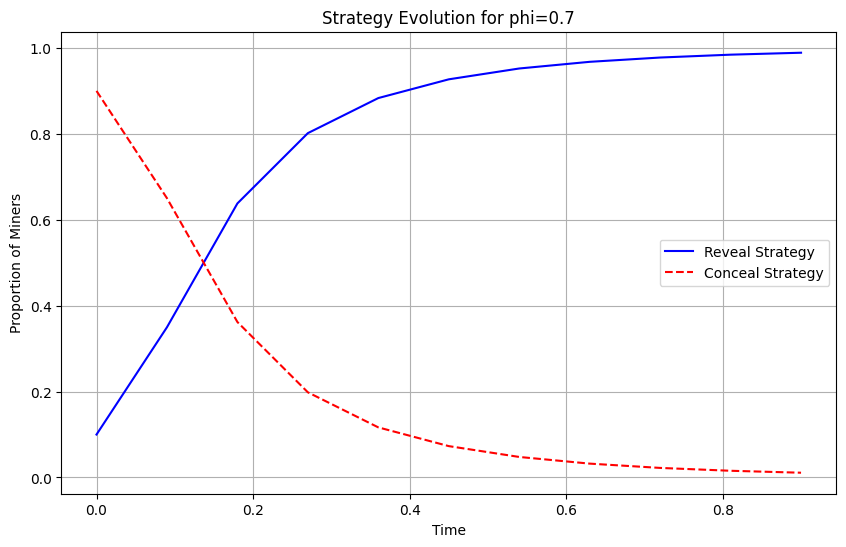


Results for phi=0.7:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.35
Time=0.18, Proportion of miners revealing=0.64
Time=0.27, Proportion of miners revealing=0.80
Time=0.36, Proportion of miners revealing=0.88
Time=0.45, Proportion of miners revealing=0.93
Time=0.54, Proportion of miners revealing=0.95
Time=0.63, Proportion of miners revealing=0.97
Time=0.72, Proportion of miners revealing=0.98
Time=0.81, Proportion of miners revealing=0.98
Time=0.90, Proportion of miners revealing=0.99


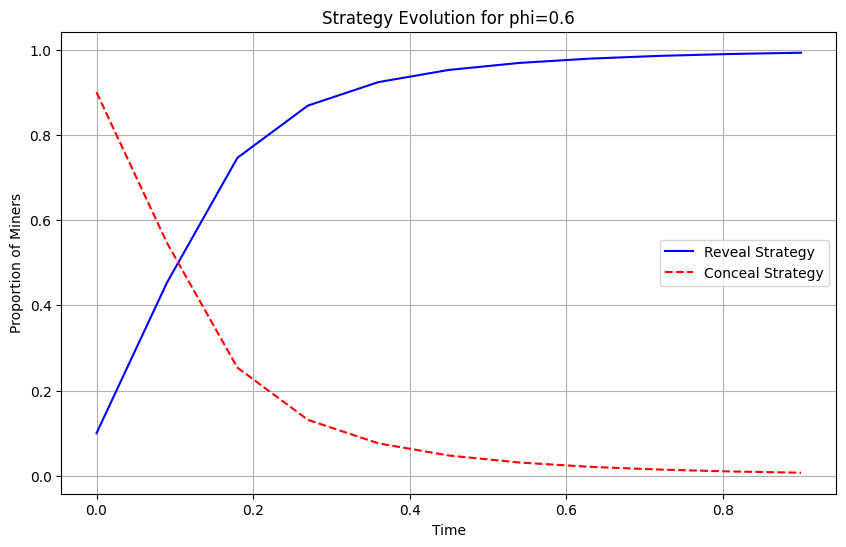


Results for phi=0.6:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.45
Time=0.18, Proportion of miners revealing=0.75
Time=0.27, Proportion of miners revealing=0.87
Time=0.36, Proportion of miners revealing=0.92
Time=0.45, Proportion of miners revealing=0.95
Time=0.54, Proportion of miners revealing=0.97
Time=0.63, Proportion of miners revealing=0.98
Time=0.72, Proportion of miners revealing=0.99
Time=0.81, Proportion of miners revealing=0.99
Time=0.90, Proportion of miners revealing=0.99


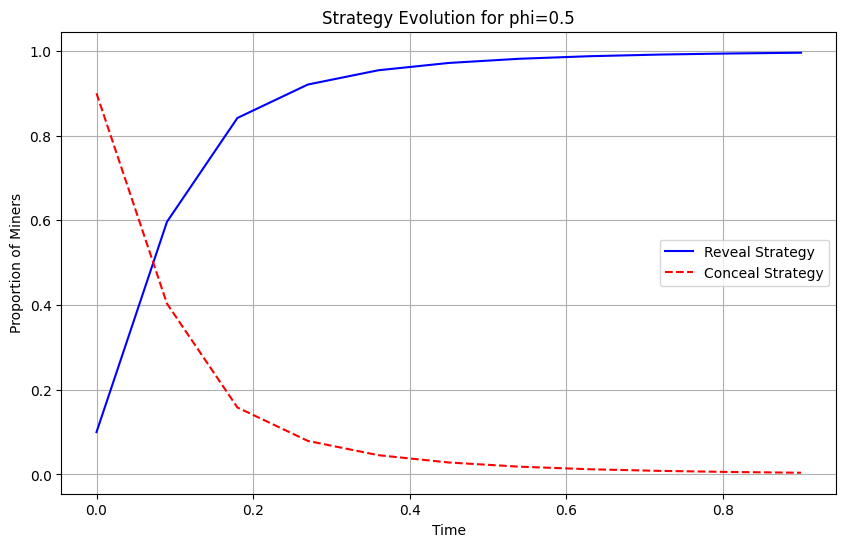


Results for phi=0.5:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.60
Time=0.18, Proportion of miners revealing=0.84
Time=0.27, Proportion of miners revealing=0.92
Time=0.36, Proportion of miners revealing=0.95
Time=0.45, Proportion of miners revealing=0.97
Time=0.54, Proportion of miners revealing=0.98
Time=0.63, Proportion of miners revealing=0.99
Time=0.72, Proportion of miners revealing=0.99
Time=0.81, Proportion of miners revealing=0.99
Time=0.90, Proportion of miners revealing=1.00


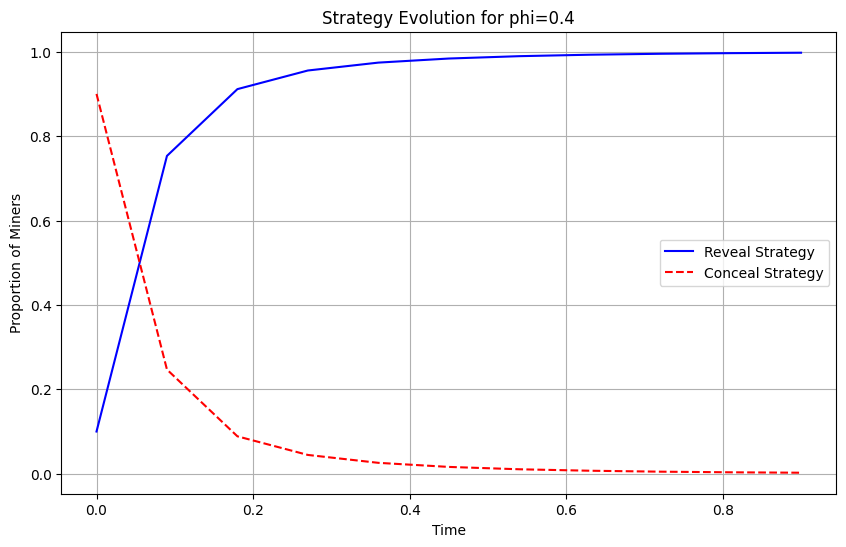


Results for phi=0.4:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.75
Time=0.18, Proportion of miners revealing=0.91
Time=0.27, Proportion of miners revealing=0.96
Time=0.36, Proportion of miners revealing=0.97
Time=0.45, Proportion of miners revealing=0.98
Time=0.54, Proportion of miners revealing=0.99
Time=0.63, Proportion of miners revealing=0.99
Time=0.72, Proportion of miners revealing=1.00
Time=0.81, Proportion of miners revealing=1.00
Time=0.90, Proportion of miners revealing=1.00


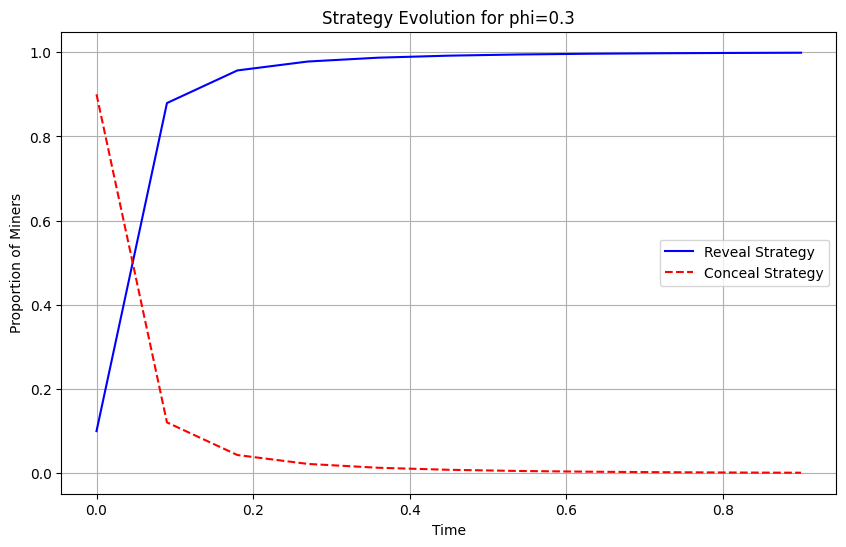


Results for phi=0.3:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.88
Time=0.18, Proportion of miners revealing=0.96
Time=0.27, Proportion of miners revealing=0.98
Time=0.36, Proportion of miners revealing=0.99
Time=0.45, Proportion of miners revealing=0.99
Time=0.54, Proportion of miners revealing=0.99
Time=0.63, Proportion of miners revealing=1.00
Time=0.72, Proportion of miners revealing=1.00
Time=0.81, Proportion of miners revealing=1.00
Time=0.90, Proportion of miners revealing=1.00


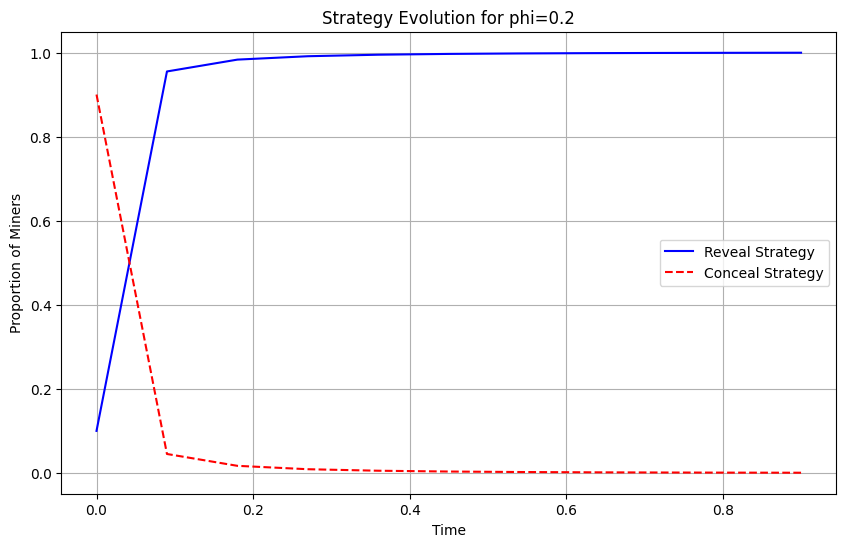


Results for phi=0.2:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.95
Time=0.18, Proportion of miners revealing=0.98
Time=0.27, Proportion of miners revealing=0.99
Time=0.36, Proportion of miners revealing=0.99
Time=0.45, Proportion of miners revealing=1.00
Time=0.54, Proportion of miners revealing=1.00
Time=0.63, Proportion of miners revealing=1.00
Time=0.72, Proportion of miners revealing=1.00
Time=0.81, Proportion of miners revealing=1.00
Time=0.90, Proportion of miners revealing=1.00


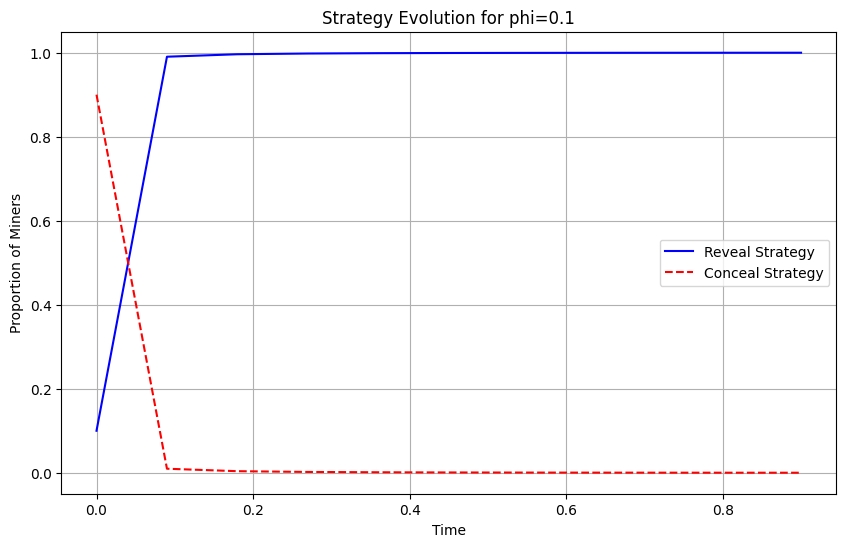


Results for phi=0.1:
Time=0.00, Proportion of miners revealing=0.10
Time=0.09, Proportion of miners revealing=0.99
Time=0.18, Proportion of miners revealing=1.00
Time=0.27, Proportion of miners revealing=1.00
Time=0.36, Proportion of miners revealing=1.00
Time=0.45, Proportion of miners revealing=1.00
Time=0.54, Proportion of miners revealing=1.00
Time=0.63, Proportion of miners revealing=1.00
Time=0.72, Proportion of miners revealing=1.00
Time=0.81, Proportion of miners revealing=1.00
Time=0.90, Proportion of miners revealing=1.00


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Base reputation impact

# Function for dynamic punishment calculation based on time and phi(t)
def calculate_punishment(phi_t, t, base_punishment=1.0):
    """Calculate punishment P as (1 / phi(t)^2) * r, increased over time."""
    time_factor = 1 + t  # Punishment increases with time
    return base_punishment * (1 / phi_t**2) * r * time_factor

# Reputation function that varies based on past actions
def calculate_reputation(reveal, historical_reveal_count):
    """Adjust reputation based on historical reveal actions."""
    dynamic_rep = rep_base * (1 + 0.1 * historical_reveal_count)  # Increases with consistent reveals
    return dynamic_rep if reveal else -dynamic_rep

# Payoff functions with variable reputation
def pi_R(x, phi_t, historical_reveal_count):
    """Payoff for using the Reveal strategy, including dynamic reputation."""
    rep = calculate_reputation(True, historical_reveal_count)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P, historical_reveal_count):
    """Payoff for using the Conceal strategy, including dynamic reputation."""
    rep = calculate_reputation(False, historical_reveal_count)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P, historical_reveal_count):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t, historical_reveal_count) + (1 - x) * pi_C(x, phi_t, P, historical_reveal_count)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t, historical_reveal_count):
    P = calculate_punishment(phi_t, t)  # Update punishment for current phi(t) and time
    pi_R_x = pi_R(x, phi_t, historical_reveal_count)
    avg_pi = average_payoff(x, phi_t, P, historical_reveal_count)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1
historical_reveal_count = 0  # Track the number of historical reveals

# Time points for simulation
time_points = np.linspace(0, 0.9, 11)

# Values of phi(t) to simulate in reverse order (0.9 to 0.1)
phi_values = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

# Plot separate figures for each value of phi(t)
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t, historical_reveal_count))

    # Update historical reveal count based on the average proportion of revealing miners
    historical_reveal_count = int(np.mean(x_trajectory) * 10)

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Create a new figure for each phi(t)
    plt.figure(figsize=(10, 6))
    
    # Plot the results for "Reveal" and "Conceal" strategies
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy", color='b')
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy", color='r')
    
    # Plot settings
    plt.xlabel('Time')
    plt.ylabel('Proportion of Miners')
    plt.title(f'Strategy Evolution for phi={phi_t}')
    plt.grid(True)
    # Adjust the legend position
    plt.legend(loc='center right', bbox_to_anchor=(1, 0.5))
    
    # Save the figure as a PDF for each phi(t)
    plt.savefig(f'strategy_evolution_phi_{phi_t}.pdf', format='pdf')
    
    # Show the plot
    plt.show()

    # Print the results for this phi(t)
    print(f"\nResults for phi={phi_t}:")
    for t, x in zip(time_points, x_trajectory):
        print(f"Time={t:.2f}, Proportion of miners revealing={x[0]:.2f}")


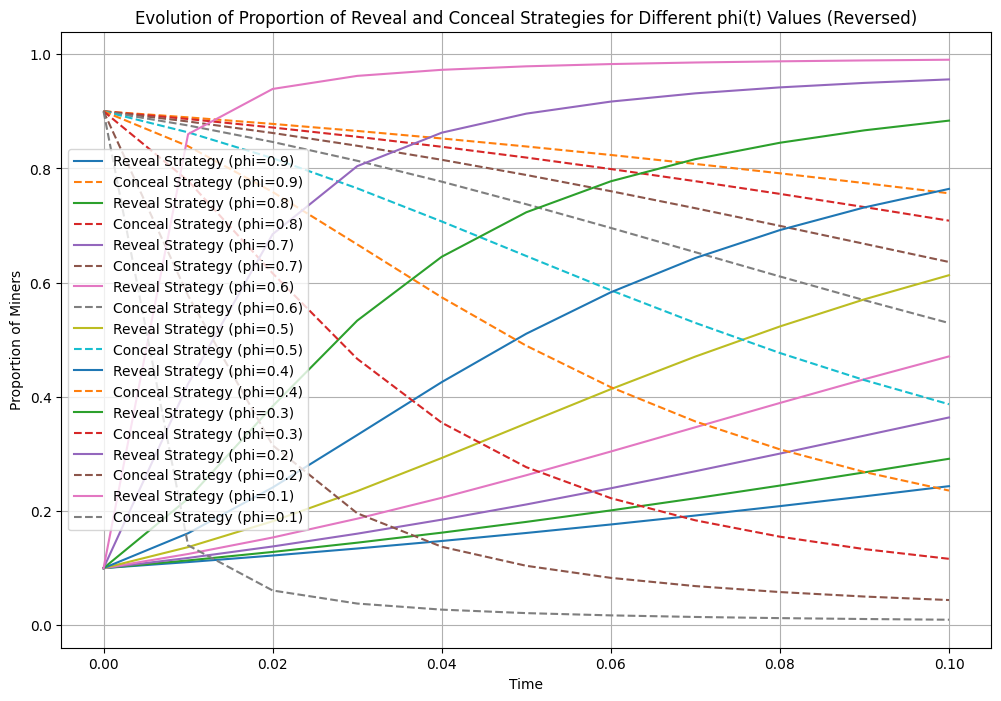

phi=0.9, Time=0.00, Proportion of miners revealing=0.10
phi=0.9, Time=0.01, Proportion of miners revealing=0.11
phi=0.9, Time=0.02, Proportion of miners revealing=0.12
phi=0.9, Time=0.03, Proportion of miners revealing=0.13
phi=0.9, Time=0.04, Proportion of miners revealing=0.15
phi=0.9, Time=0.05, Proportion of miners revealing=0.16
phi=0.9, Time=0.06, Proportion of miners revealing=0.18
phi=0.9, Time=0.07, Proportion of miners revealing=0.19
phi=0.9, Time=0.08, Proportion of miners revealing=0.21
phi=0.9, Time=0.09, Proportion of miners revealing=0.23
phi=0.9, Time=0.10, Proportion of miners revealing=0.24
phi=0.8, Time=0.00, Proportion of miners revealing=0.10
phi=0.8, Time=0.01, Proportion of miners revealing=0.11
phi=0.8, Time=0.02, Proportion of miners revealing=0.13
phi=0.8, Time=0.03, Proportion of miners revealing=0.14
phi=0.8, Time=0.04, Proportion of miners revealing=0.16
phi=0.8, Time=0.05, Proportion of miners revealing=0.18
phi=0.8, Time=0.06, Proportion of miners reveali

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 0.1, 11)

# Values of phi(t) to simulate in reverse order (0.9 to 0.1)
phi_values = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Plot the results for "Reveal" and "Conceal" strategies
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies for Different phi(t) Values (Reversed)')
plt.grid(True)
plt.legend()

# Save the figure as a PDF
plt.savefig('strategy_evolution_reversed_phi.pdf', format='pdf')

# Show the plot
plt.show()

# Print the convergence information for the chosen time points
for phi_t in phi_values:
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))
    for t, x in zip(time_points, x_trajectory):
        print(f"phi={phi_t}, Time={t:.2f}, Proportion of miners revealing={x[0]:.2f}")


In [ ]:
# we change the range of time from 0-50 to 0-5:

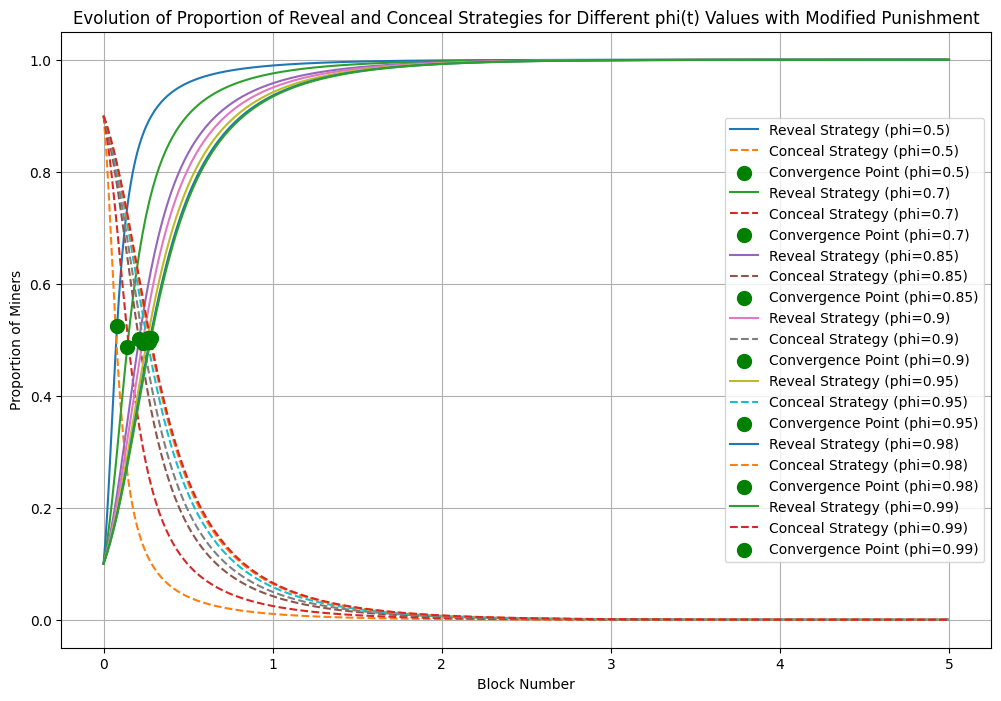

Convergence for phi=0.5: Block Number = 0.08, Proportion of miners revealing = 0.52
Convergence for phi=0.7: Block Number = 0.14, Proportion of miners revealing = 0.49
Convergence for phi=0.85: Block Number = 0.21, Proportion of miners revealing = 0.50
Convergence for phi=0.9: Block Number = 0.23, Proportion of miners revealing = 0.49
Convergence for phi=0.95: Block Number = 0.26, Proportion of miners revealing = 0.50
Convergence for phi=0.98: Block Number = 0.27, Proportion of miners revealing = 0.50
Convergence for phi=0.99: Block Number = 0.28, Proportion of miners revealing = 0.50


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation (scaled to represent block numbers 0 to 5)
time_points = np.linspace(0, 5, 500)  # From 0 to 5 blocks

# Values of phi(t) to simulate (closer to 1)
phi_values = [0.5, 0.7, 0.85, 0.9, 0.95, 0.98, 0.99]

# List to store convergence information
convergence_info = []

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]  # This now reflects the block number
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")
    plt.scatter(intersection_time, intersection_value, color='green', s=100, label=f"Convergence Point (phi={phi_t})", zorder=5)

# Plot settings
plt.xlabel('Block Number')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies for Different phi(t) Values with Modified Punishment')
plt.grid(True)
plt.legend()
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Block Number = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [ ]:
# change block number back to time:

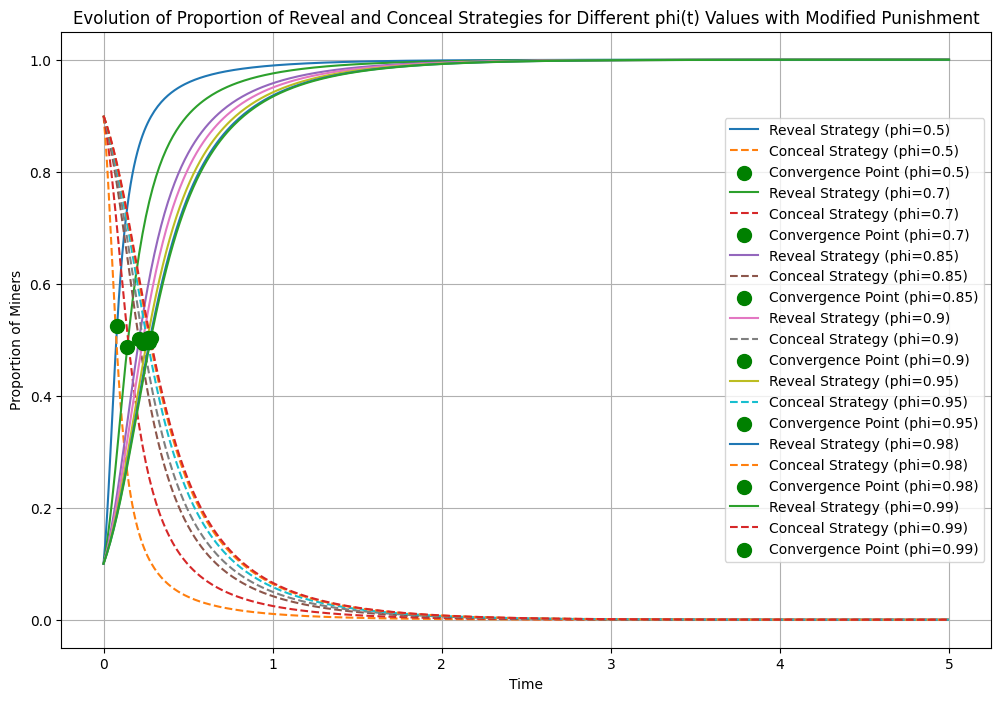

Convergence for phi=0.5: Time = 0.08, Proportion of miners revealing = 0.52
Convergence for phi=0.7: Time = 0.14, Proportion of miners revealing = 0.49
Convergence for phi=0.85: Time = 0.21, Proportion of miners revealing = 0.50
Convergence for phi=0.9: Time = 0.23, Proportion of miners revealing = 0.49
Convergence for phi=0.95: Time = 0.26, Proportion of miners revealing = 0.50
Convergence for phi=0.98: Time = 0.27, Proportion of miners revealing = 0.50
Convergence for phi=0.99: Time = 0.28, Proportion of miners revealing = 0.50


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing

# Function for punishment calculation based on phi(t)
def calculate_punishment(phi_t, r):
    """Calculate punishment P as (1 / phi(t)^2) * r."""
    return (1 / phi_t**2) * r

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t):
    P = calculate_punishment(phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation (continuous time range from 0 to 5)
time_points = np.linspace(0, 5, 500)  # Time from 0 to 5

# Values of phi(t) to simulate (closer to 1)
phi_values = [0.5, 0.7, 0.85, 0.9, 0.95, 0.98, 0.99]

# List to store convergence information
convergence_info = []

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t,))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]  # Time of convergence
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")
    plt.scatter(intersection_time, intersection_value, color='green', s=100, label=f"Convergence Point (phi={phi_t})", zorder=5)

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies for Different phi(t) Values with Modified Punishment')
plt.grid(True)
plt.legend()
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [ ]:
## the above code is good, but i wanna check if we use history dependent punishment:

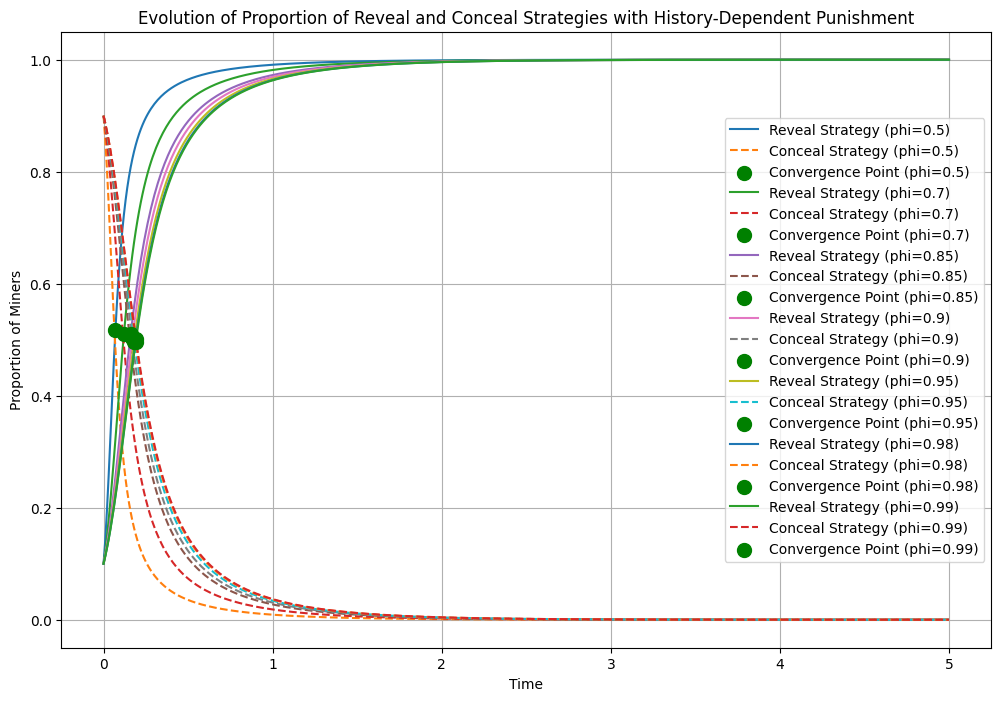

Convergence for phi=0.5: Time = 0.07, Proportion of miners revealing = 0.52
Convergence for phi=0.7: Time = 0.12, Proportion of miners revealing = 0.51
Convergence for phi=0.85: Time = 0.16, Proportion of miners revealing = 0.51
Convergence for phi=0.9: Time = 0.17, Proportion of miners revealing = 0.50
Convergence for phi=0.95: Time = 0.18, Proportion of miners revealing = 0.50
Convergence for phi=0.98: Time = 0.19, Proportion of miners revealing = 0.50
Convergence for phi=0.99: Time = 0.19, Proportion of miners revealing = 0.50


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
rep_base = 1.0  # Reputation impact for revealing
base_penalty = 5.0  # Base penalty for concealing

# Function for history-dependent punishment calculation
def calculate_punishment(phi_t, r, conceal_rounds):
    """Calculate history-dependent punishment based on the number of concealment rounds."""
    return (1 / phi_t**2) * r + base_penalty * np.sqrt(conceal_rounds + 1)

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions with reputation
def pi_R(x, phi_t):
    """Payoff for using the Reveal strategy, including reputation."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P):
    """Payoff for using the Conceal strategy, including reputation."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t) + (1 - x) * pi_C(x, phi_t, P)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t, conceal_rounds):
    # Update punishment for current phi(t) with history dependence
    P = calculate_punishment(phi_t, r, conceal_rounds)
    pi_R_x = pi_R(x, phi_t)
    avg_pi = average_payoff(x, phi_t, P)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation (continuous time range from 0 to 5)
time_points = np.linspace(0, 5, 500)  # Time from 0 to 5

# Values of phi(t) to simulate (closer to 1)
phi_values = [0.5, 0.7, 0.85, 0.9, 0.95, 0.98, 0.99]

# List to store convergence information
convergence_info = []

# Track the number of consecutive concealment rounds
conceal_rounds = 0

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Initialize conceal_rounds for each phi value
    conceal_rounds = 0

    # List to store the trajectory for updating conceal_rounds
    x_trajectory_list = []

    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t, conceal_rounds))

    # Update conceal_rounds based on the trajectory
    for i in range(1, len(x_trajectory)):
        if x_trajectory[i] < 0.5:
            conceal_rounds += 1  # Increment conceal_rounds if more than half choose conceal
        else:
            conceal_rounds = 0  # Reset if reveal is chosen by most miners

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]  # Time of convergence
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")
    plt.scatter(intersection_time, intersection_value, color='green', s=100, label=f"Convergence Point (phi={phi_t})", zorder=5)

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies with History-Dependent Punishment')
plt.grid(True)
plt.legend()
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [ ]:
### histroy dependent reputation system - history dependent punishment system, variable phi function

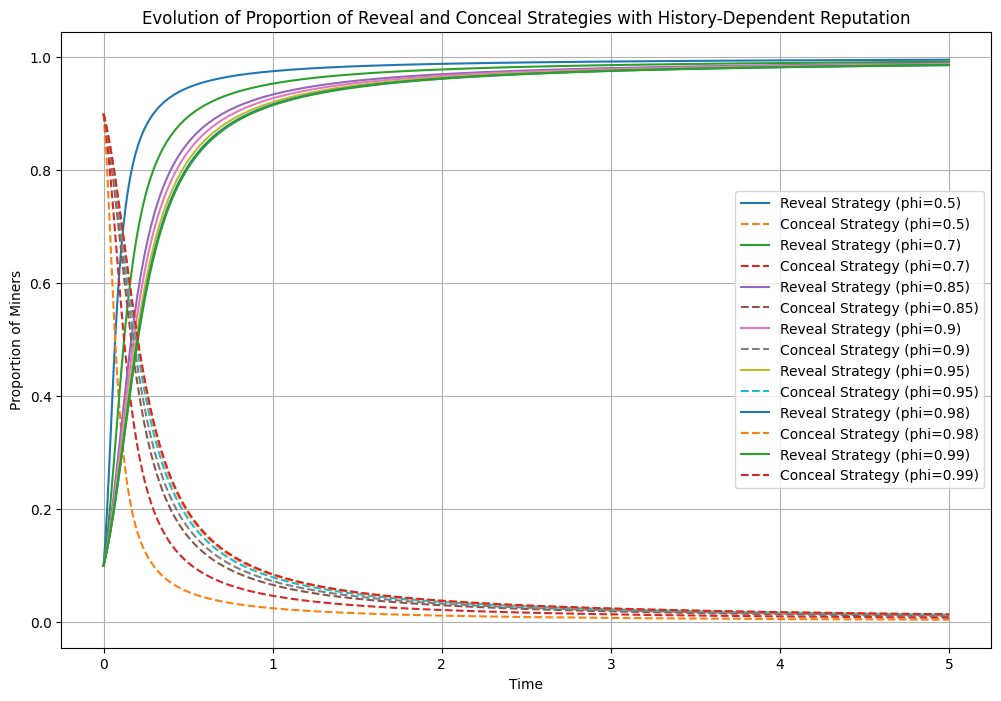

Convergence for phi=0.5: Time = 0.07, Proportion of miners revealing = 0.51
Convergence for phi=0.7: Time = 0.12, Proportion of miners revealing = 0.50
Convergence for phi=0.85: Time = 0.16, Proportion of miners revealing = 0.49
Convergence for phi=0.9: Time = 0.18, Proportion of miners revealing = 0.51
Convergence for phi=0.95: Time = 0.19, Proportion of miners revealing = 0.50
Convergence for phi=0.98: Time = 0.20, Proportion of miners revealing = 0.50
Convergence for phi=0.99: Time = 0.20, Proportion of miners revealing = 0.50


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
base_penalty = 5.0  # Base penalty for concealing

# Function for history-dependent punishment calculation
def calculate_punishment(phi_t, r, conceal_rounds):
    """Calculate history-dependent punishment based on the number of concealment rounds."""
    return (1 / phi_t**2) * r + base_penalty * np.sqrt(conceal_rounds + 1)

# Update reputation score based on the current action
def update_reputation(reputation, action, rep_gain=0.1, rep_loss=0.1):
    """Update the reputation score based on the miner's action.
    - Increase the reputation if the miner reveals.
    - Decrease the reputation if the miner conceals.
    """
    if action == "reveal":
        reputation += rep_gain
    elif action == "conceal":
        reputation -= rep_loss
    return reputation

# Payoff functions with history-dependent reputation
def pi_R(x, phi_t, reputation):
    """Payoff for using the Reveal strategy, incorporating reputation."""
    return x * (phi_t * r - C_d + reputation) + (1 - x) * (-C_a + reputation)

def pi_C(x, phi_t, P, reputation):
    """Payoff for using the Conceal strategy, incorporating reputation."""
    return x * (phi_t * r - C_d + reputation) + (1 - x) * (-C_a - P - reputation)

def average_payoff(x, phi_t, P, reputation):
    """Average payoff across the population, including reputation."""
    return x * pi_R(x, phi_t, reputation) + (1 - x) * pi_C(x, phi_t, P, reputation)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t, conceal_rounds, reputation):
    # Update punishment for current phi(t) with history dependence
    P = calculate_punishment(phi_t, r, conceal_rounds)
    pi_R_x = pi_R(x, phi_t, reputation)
    avg_pi = average_payoff(x, phi_t, P, reputation)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1
# Initial reputation score
reputation = 0.0

# Time points for simulation (continuous time range from 0 to 5)
time_points = np.linspace(0, 5, 500)  # Time from 0 to 5

# Values of phi(t) to simulate (closer to 1)
phi_values = [0.5, 0.7, 0.85, 0.9, 0.95, 0.98, 0.99]

# List to store convergence information
convergence_info = []

# Track the number of consecutive concealment rounds
conceal_rounds = 0

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Initialize conceal_rounds and reputation for each phi value
    conceal_rounds = 0
    reputation = 0.0

    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t, conceal_rounds, reputation))

    # Update conceal_rounds and reputation based on the trajectory
    for i in range(1, len(x_trajectory)):
        if x_trajectory[i] < 0.5:
            conceal_rounds += 1  # Increment conceal_rounds if more than half choose conceal
            reputation = update_reputation(reputation, "conceal")  # Update reputation for concealing
        else:
            conceal_rounds = 0  # Reset if reveal is chosen by most miners
            reputation = update_reputation(reputation, "reveal")  # Update reputation for revealing

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Find the intersection point where reveal and conceal proportions are equal
    intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
    intersection_time = time_points[intersection_idx]  # Time of convergence
    intersection_value = x_trajectory[intersection_idx][0]

    # Store the convergence information
    convergence_info.append((phi_t, intersection_time, intersection_value))

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies with History-Dependent Reputation')
plt.grid(True)
plt.legend()
plt.show()

# Print the convergence point information
for phi_t, time, value in convergence_info:
    print(f"Convergence for phi={phi_t}: Time = {time:.2f}, Proportion of miners revealing = {value:.2f}")


In [17]:
# Now we wanna make it complex to add reputation system

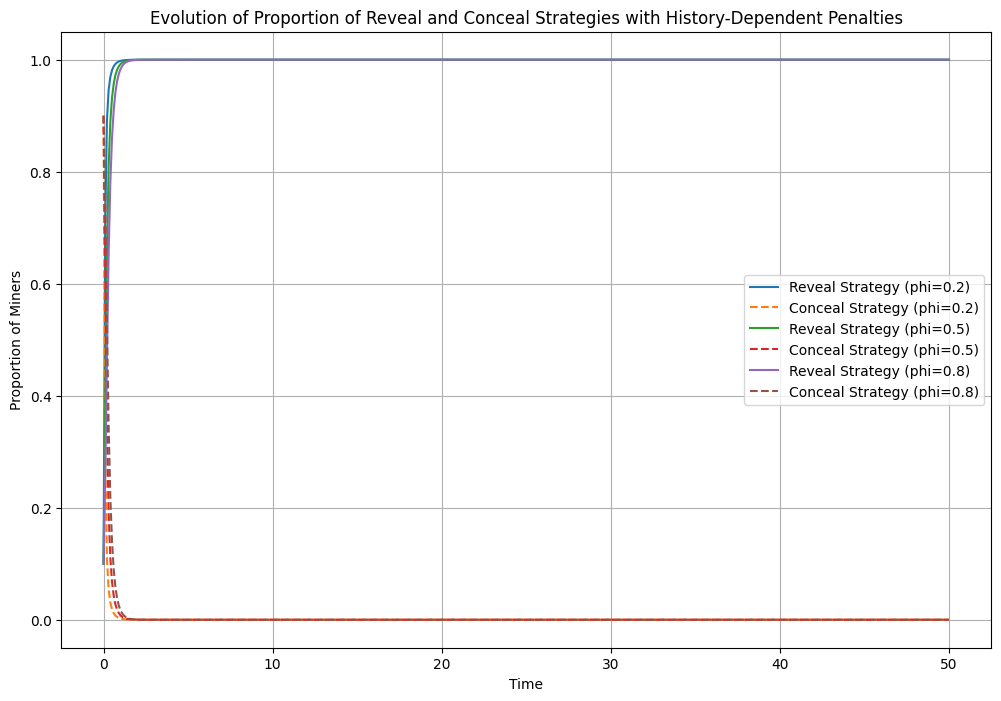

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
base_penalty = 5.0  # Base penalty for concealing
rep_base = 2.0  # Base reputation value for revealing

# Function for punishment calculation based on history
def calculate_punishment(conceal_rounds, phi_t, r):
    """Calculate history-dependent punishment based on the number of concealment rounds."""
    return (1 / phi_t) * r + base_penalty * conceal_rounds

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions
def pi_R(x, phi_t, conceal_rounds):
    """Payoff for using the Reveal strategy."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P, conceal_rounds):
    """Payoff for using the Conceal strategy."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P, conceal_rounds):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t, conceal_rounds) + (1 - x) * pi_C(x, phi_t, P, conceal_rounds)

# Replicator equation: dx/dt = x * (pi_R - avg_pi)
def replicator_dynamics(x, t, phi_t, conceal_rounds):
    P = calculate_punishment(conceal_rounds, phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t, conceal_rounds)
    avg_pi = average_payoff(x, phi_t, P, conceal_rounds)
    dxdt = x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 50, 500)

# Values of phi(t) to simulate
phi_values = [0.2, 0.5, 0.8]  # Different values of phi(t) between 0 and 1

# Concealment history (tracking consecutive concealment rounds)
conceal_rounds = 0

# Plot the results for different values of phi(t)
plt.figure(figsize=(12, 8))
for phi_t in phi_values:
    # Reset conceal_rounds for each phi value simulation
    conceal_rounds = 0

    # Solve the replicator dynamics equation using odeint
    x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t, conceal_rounds))

    # Calculate the proportion of miners using the Conceal strategy
    conceal_trajectory = 1 - x_trajectory

    # Plot the results
    plt.plot(time_points, x_trajectory, label=f"Reveal Strategy (phi={phi_t})")
    plt.plot(time_points, conceal_trajectory, linestyle='--', label=f"Conceal Strategy (phi={phi_t})")

# Plot settings
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies with History-Dependent Penalties')
plt.grid(True)
plt.legend()
plt.show()


In [25]:
############ show the touch point/

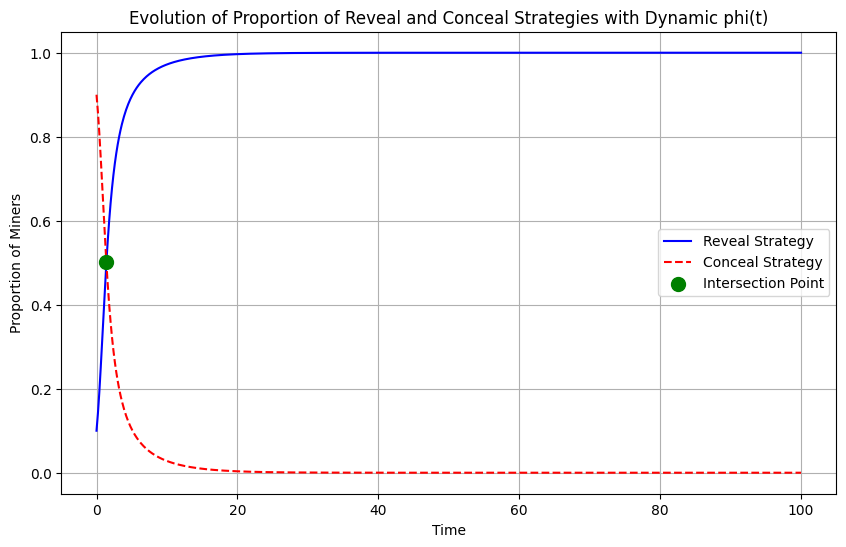

Intersection occurs at time t = 1.40, where the proportion of miners is 0.50.


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
base_penalty = 2.0  # Reduced base penalty for concealing
rep_base = 1.0  # Reduced base reputation value for revealing
smoothing_factor = 0.1  # Smoothing factor for replicator dynamics

# Function for dynamic phi(t)
def phi(t):
    """Varying phi(t) as a function of time."""
    return 0.5 + 0.5 * np.sin(2 * np.pi * t / 100)  # Smoothly varies between 0 and 1

# Function for punishment calculation based on history
def calculate_punishment(conceal_rounds, phi_t, r):
    """Calculate a smoother history-dependent punishment using a square root function."""
    return (1 / phi_t) * r + base_penalty * np.sqrt(conceal_rounds + 1)

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions
def pi_R(x, phi_t, conceal_rounds):
    """Payoff for using the Reveal strategy."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P, conceal_rounds):
    """Payoff for using the Conceal strategy."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P, conceal_rounds):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t, conceal_rounds) + (1 - x) * pi_C(x, phi_t, P, conceal_rounds)

# Replicator equation: dx/dt = x * (pi_R - avg_pi) with a smoothing factor
def replicator_dynamics(x, t, conceal_rounds):
    current_phi = phi(t)  # Get the current value of phi(t)
    P = calculate_punishment(conceal_rounds, current_phi, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, current_phi, conceal_rounds)
    avg_pi = average_payoff(x, current_phi, P, conceal_rounds)
    dxdt = smoothing_factor * x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 100, 1000)

# Concealment history (tracking consecutive concealment rounds)
conceal_rounds = 0

# Solve the replicator dynamics equation using odeint
x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(conceal_rounds,))

# Calculate the proportion of miners using the Conceal strategy
conceal_trajectory = 1 - x_trajectory

# Find the intersection point where reveal and conceal proportions are equal
intersection_idx = np.argmin(np.abs(x_trajectory - conceal_trajectory))
intersection_time = time_points[intersection_idx]
intersection_value = x_trajectory[intersection_idx]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, x_trajectory, label="Reveal Strategy", color='blue')
plt.plot(time_points, conceal_trajectory, label="Conceal Strategy", linestyle='--', color='red')
plt.scatter(intersection_time, intersection_value, color='green', s=100, label="Intersection Point", zorder=5)
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies with Dynamic phi(t)')
plt.grid(True)
plt.legend()
plt.show()

# Print the intersection details
# Print the intersection details
print(f"Intersection occurs at time t = {intersection_time:.2f}, where the proportion of miners is {intersection_value.item():.2f}.")


In [24]:
#### make it simpler by considering a constant phi 0.5

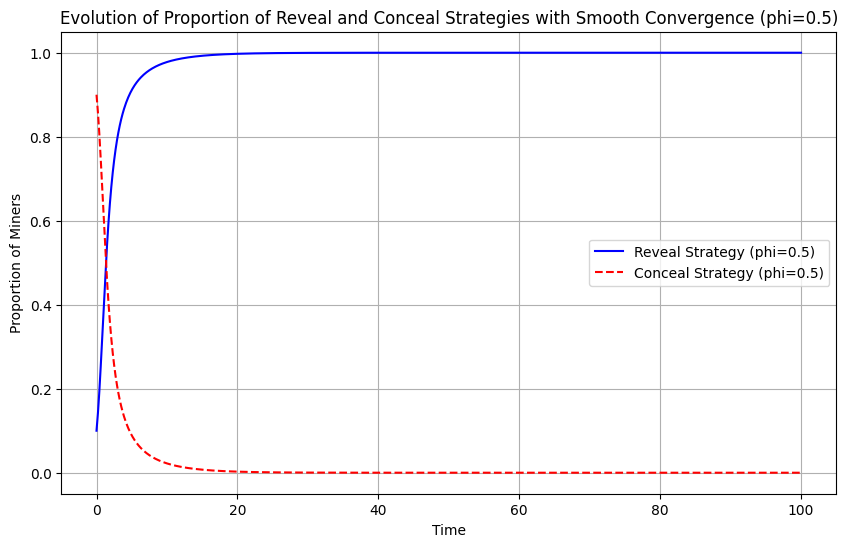

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
base_penalty = 2.0  # Reduced base penalty for concealing
rep_base = 1.0  # Reduced base reputation value for revealing
phi_t = 0.5  # Fixed value for phi(t)
smoothing_factor = 0.1  # Smoothing factor for replicator dynamics

# Function for punishment calculation based on history
def calculate_punishment(conceal_rounds, phi_t, r):
    """Calculate a smoother history-dependent punishment using a square root function."""
    return (1 / phi_t) * r + base_penalty * np.sqrt(conceal_rounds + 1)

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions
def pi_R(x, phi_t, conceal_rounds):
    """Payoff for using the Reveal strategy."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P, conceal_rounds):
    """Payoff for using the Conceal strategy."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P, conceal_rounds):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t, conceal_rounds) + (1 - x) * pi_C(x, phi_t, P, conceal_rounds)

# Replicator equation: dx/dt = x * (pi_R - avg_pi) with a smoothing factor
def replicator_dynamics(x, t, phi_t, conceal_rounds):
    P = calculate_punishment(conceal_rounds, phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t, conceal_rounds)
    avg_pi = average_payoff(x, phi_t, P, conceal_rounds)
    dxdt = smoothing_factor * x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 100, 1000)

# Concealment history (tracking consecutive concealment rounds)
conceal_rounds = 0

# Solve the replicator dynamics equation using odeint
x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t, conceal_rounds))

# Calculate the proportion of miners using the Conceal strategy
conceal_trajectory = 1 - x_trajectory

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, x_trajectory, label="Reveal Strategy (phi=0.5)", color='blue')
plt.plot(time_points, conceal_trajectory, label="Conceal Strategy (phi=0.5)", linestyle='--', color='red')
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies with Smooth Convergence (phi=0.5)')
plt.grid(True)
plt.legend()
plt.show()


In [22]:
### now we wanna show where these two curve touch

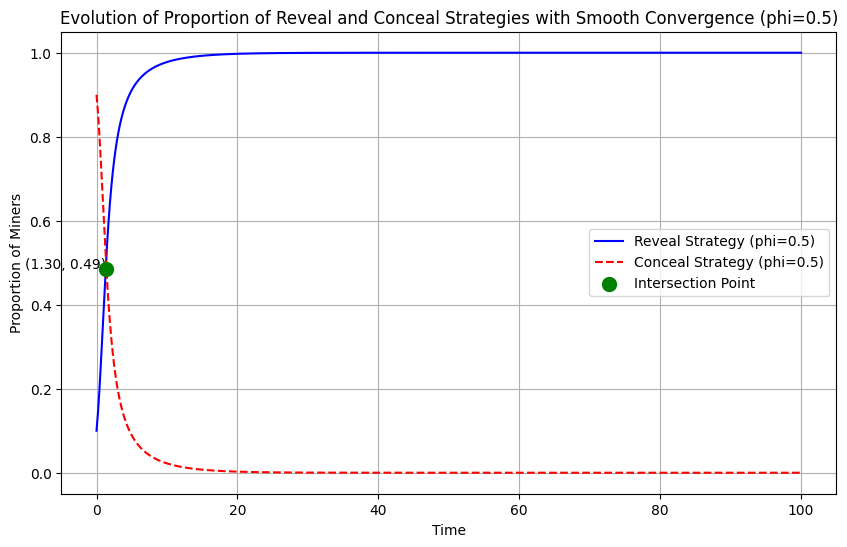

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r = 10.0    # Reward for mining a block
C_a = 4.0   # Cost for the attacker
C_d = 3.0   # Cost for the defender
base_penalty = 2.0  # Reduced base penalty for concealing
rep_base = 1.0  # Reduced base reputation value for revealing
phi_t = 0.5  # Fixed value for phi(t)
smoothing_factor = 0.1  # Smoothing factor for replicator dynamics

# Function for punishment calculation based on history
def calculate_punishment(conceal_rounds, phi_t, r):
    """Calculate a smoother history-dependent punishment using a square root function."""
    return (1 / phi_t) * r + base_penalty * np.sqrt(conceal_rounds + 1)

# Reputation function
def calculate_reputation(reveal):
    """Calculate reputation: positive if revealing, negative if concealing."""
    return rep_base if reveal else -rep_base

# Payoff functions
def pi_R(x, phi_t, conceal_rounds):
    """Payoff for using the Reveal strategy."""
    rep = calculate_reputation(True)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a + rep)

def pi_C(x, phi_t, P, conceal_rounds):
    """Payoff for using the Conceal strategy."""
    rep = calculate_reputation(False)
    return x * (phi_t * r - C_d + rep) + (1 - x) * (-C_a - P - rep)

def average_payoff(x, phi_t, P, conceal_rounds):
    """Average payoff across the population."""
    return x * pi_R(x, phi_t, conceal_rounds) + (1 - x) * pi_C(x, phi_t, P, conceal_rounds)

# Replicator equation: dx/dt = x * (pi_R - avg_pi) with a smoothing factor
def replicator_dynamics(x, t, phi_t, conceal_rounds):
    P = calculate_punishment(conceal_rounds, phi_t, r)  # Update punishment for current phi(t)
    pi_R_x = pi_R(x, phi_t, conceal_rounds)
    avg_pi = average_payoff(x, phi_t, P, conceal_rounds)
    dxdt = smoothing_factor * x * (pi_R_x - avg_pi)
    return dxdt

# Initial proportion of miners using the Reveal strategy
x0 = 0.1

# Time points for simulation
time_points = np.linspace(0, 100, 1000)

# Concealment history (tracking consecutive concealment rounds)
conceal_rounds = 0

# Solve the replicator dynamics equation using odeint
x_trajectory = odeint(replicator_dynamics, x0, time_points, args=(phi_t, conceal_rounds)).flatten()

# Calculate the proportion of miners using the Conceal strategy
conceal_trajectory = 1 - x_trajectory

# Find the point where the reveal and conceal proportions are equal (x = 0.5)
intersection_index = np.argmin(np.abs(x_trajectory - 0.5))
intersection_time = time_points[intersection_index]
intersection_value = x_trajectory[intersection_index]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, x_trajectory, label="Reveal Strategy (phi=0.5)", color='blue')
plt.plot(time_points, conceal_trajectory, label="Conceal Strategy (phi=0.5)", linestyle='--', color='red')
plt.scatter(intersection_time, intersection_value, color='green', s=100, label='Intersection Point', zorder=5)
plt.text(intersection_time, intersection_value, f'({intersection_time:.2f}, {intersection_value:.2f})', fontsize=10, ha='right')
plt.xlabel('Time')
plt.ylabel('Proportion of Miners')
plt.title('Evolution of Proportion of Reveal and Conceal Strategies with Smooth Convergence (phi=0.5)')
plt.grid(True)
plt.legend()
plt.show()
